# 03 — The edges of the exclusion

**Paper element.** The mass window quoted in Results: its low-mass onset (the
kinematic wall) and its high-mass end (the flux cut $m_\mathrm{cut}$, stored in
the release attributes).

**What this notebook is.** One story with two ends and a map in the middle. The
excluded region of [`01_the_limit.ipynb`](01_the_limit.ipynb) is bounded on the
left by a **hard kinematic wall**, on the right by a **flux-through-aperture
cut**, and in between by a statistics floor and an atmospheric ceiling. Neither
of the two ends is in the extremeness surface: both are statements made outside
it, and both are arithmetic a reader can redo. This notebook does the arithmetic.

Everything below is derived from the analysis modules and the data release — the
released cube `luhdm_datarelease_v10_A_f1_atm.h5` ($f_\mathrm{DM} = 1$,
atmosphere applied) and its companion `luhdm_datarelease_v10_B_f0p1_noatm.h5`
($f_\mathrm{DM} = 0.1$, bare halo) — and section 10 checks that the one-line
pipeline used here reproduces the cubes' own expected-count cells, so the
figures carry the release's numbers rather than a re-derivation that could
drift. Every recomputation goes through `rel.make_xsec`, so it inherits the
cube's own projection kernel; see
[`02_how_the_limit_is_made.ipynb`](02_how_the_limit_is_made.ipynb) for what that
convention is and why mixing the two is a silent error. Every band drawn below
is **mode 1**, the mode the Letter's mass window is quoted from.

**Three numbers are not re-derived.** The left edge of the superseded 0.1 TeV
capped analysis (the historical row of the section-4 ladder) and the two closure
masses of that same analysis (section 8) come from an internal cube that is not
in `release/`. They are pinned in the code with a comment saying what they were
measured on, and they are labelled as historical anchors rather than results.

### The left edge, in one line

The analysis counts a momentum kick only if it clears the analysis threshold
$q_\mathrm{min} = 1$ TeV$/c$. A flyby of a particle of mass $m_\mathrm{DM}$
arriving at speed $v$ delivers at most $q = m_\mathrm{DM}\,v$ (the velocity mask
in `luhdm.rate.differential_rate_trapz`), and the halo has nothing above its
fastest arrival speed. This release is in the **laboratory frame**: the halo is
boosted by the Earth's motion through it, $v_E = 245$ km/s, so an arrival can be
as fast as $v_\mathrm{max} = v_\mathrm{esc} + v_E = 544 + 245 = 789$ km/s
(`config.V_MAX`; the Galactic escape speed $v_\mathrm{esc}$ = 544 km/s is the
ceiling only in the rest frame, which is what the pre-v10 releases used —
[`06_halo_frame_and_rates.ipynb`](06_halo_frame_and_rates.ipynb) compares the
two). So a particle lighter than

$$m_\mathrm{wall} \;=\; \frac{q_\mathrm{min}}{v_\mathrm{max}}
\;=\; \frac{1000\ \mathrm{GeV}}{2.6318\times10^{-3}}
\;=\; 3.80\times10^{5}\ \mathrm{GeV}$$

cannot place a single kick inside the analysis window, at any coupling, through
any mediator. Not "is hard to detect" — cannot: the expected count is exactly
zero, and the cube says so in every cell below the wall.

That is a different kind of edge from the one this analysis used to have. When the window started at 0.1 TeV the wall sat ten times lower, at
$3.8\times10^{4}$ GeV, far below where the contour actually stopped; the edge
was then set by a *soft* competition between the efficiency cliff and the
coupling, and the contour crept below any threshold estimate one cared to make.
Section 4 revisits that, because the mechanism is instructive and because the
older numbers are still in circulation.

### The right edge, in one line

The right edge is not kinematic at all. A heavier particle delivers a *harder*
kick, so nothing in the cross section stops the exclusion from running to the
Planck mass — and on the released surfaces it does exactly that: the
massless-mediator band is still excluded at the last mass on the grid. What runs
out is the *supply*. At fixed local density $\rho_0$ the number density falls as
$1/m_\mathrm{DM}$, so a heavy enough particle simply does not pass close to the
sensor during the exposure, however strongly it couples when it does. Over an
aperture of radius $b_\mathrm{cap}$,

$$N(m_\mathrm{DM}) \;=\; f_\mathrm{DM}\,\frac{\rho_0}{m_\mathrm{DM}}\,
\langle v \rangle\, T_\mathrm{obs}\, \pi\, b_\mathrm{cap}^{2},
\qquad
m_\mathrm{cut} \;=\; \frac{f_\mathrm{DM}\,\rho_0\,\langle v \rangle\,
T_\mathrm{obs}\,\pi\,b_\mathrm{cap}^{2}}{N_\mathrm{req}} .$$

This is a statement about the flux, not about the cross section, which is why it
is applied as a *post-facto* cut in mass rather than as a cap inside the
impact-parameter integral. The stored $\mu$ and extremeness surfaces are
uncapped and auditable; $m_\mathrm{cut}$ is a line drawn on top of them, and a
reader who disagrees with the choice of $N_\mathrm{req}$ can move it.

**The assumption, stated up front.** The released files carry
$N_\mathrm{req} = 3$, matching the Poisson-zero standard the limit itself uses
($-\ln 0.05 = 3.0$ expected counts). That choice is an assumption, not a
derivation. The alternative kept in view throughout is $N_\mathrm{req} = 6.8$,
the value that reproduces the closure of the superseded capped analysis. Both
lines are drawn on every figure below, and section 8 shows what separates them.

| | section | question |
|---|---|---|
| **left edge** | 1 | The wall: where it is, and how hard |
| | 2 | Where the measured left edge actually sits |
| | 3 | The onset just above the wall: the halo's velocity tail |
| | 4 | Retrospective: why the 0.1 TeV window had a soft edge |
| **the map between** | 5 | Transit-count and reach maps: every edge on one plane |
| **right edge** | 6 | The transit curve $N(m_\mathrm{DM})$, and where the two cuts fall |
| | 7 | The uncapped contour against the cut |
| | 8 | The superseded capped closure, and what $N_\mathrm{req}$ buys |
| | 9 | The shell of validity: why the aperture is 10 cm |
| **both** | 10 | Numerical self-consistency checks |

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np

from luhdm import config, efficiency, halo, limits, rate, units
from luhdm import release

# The released cube. File A is the f_DM = 1 surface with the atmosphere applied
# (the presentation convention of the Letter); file B is the f_DM = 0.1
# atmosphere-off companion, used from section 2 onwards.
PATH_A = "../release/luhdm_datarelease_v10_A_f1_atm.h5"
PATH_B = "../release/luhdm_datarelease_v10_B_f0p1_noatm.h5"

rel = release.open_release(PATH_A)     # f_DM = 1, atmosphere applied
relB = release.open_release(PATH_B)    # f_DM = 0.1, no atmosphere

# The halo frame is a property of the files, and this release is built in
# the LAB frame (v_earth = 245 km/s): the arrival distribution is the
# Earth-boosted one and reaches v_esc + v_E, not v_esc. Every speed integral,
# every kinematic ceiling and the wall itself below depend on it, so it is
# read off the file and applied to luhdm.config before any of them are
# formed. Recomputing under the rest-frame default would truncate the
# boosted tail and disagree with the cube (check 2 of section 10 is exactly
# that comparison).
assert relB.v_earth_km_s == rel.v_earth_km_s, \
    "the two released files are in different halo frames"
config.set_v_earth_km_s(rel.v_earth_km_s)

# --- fiducials, all read from luhdm.config / the release file ----------------
VESC = config.VESC                    # Galactic escape speed, 544 km/s in c
V_E = config.V_E                      # Earth's speed through the halo, in c
V_MAX = config.V_MAX                  # = VESC + V_E: the fastest arrival the
                                      # halo frame of these files supports,
                                      # and the ceiling of every speed
                                      # integral below
Q_MIN = config.Q_THRESH               # analysis threshold, 1 TeV [GeV]
T_TOTAL = config.T_EXPOSURE           # live-time of the candidate lists [s]
N_N = config.N_NEUTRONS               # neutrons in the magnet (alpha = alpha_n N_n)
R_EFF = config.R_EFF                  # sensor radius [m] (inner b-integral edge)
CONV = units.conv_m2pGeV(1.0)         # 1 m in GeV^-1
MODE = 1                              # every band and figure below
CONFIDENCE = 0.95
M_PLANCK = float(rel.attrs["m_planck_gev"])
F_DM = 1.0                            # the plane this file carries
SCALE_F1 = F_DM / config.F_X

# the cross section carries no impact-parameter cap in this release
assert rel.b_constrained_max is None, "this cube is capped; this notebook needs the uncapped release"

# the two masses the kinematics single out
M_WALL = Q_MIN / V_MAX                # nothing lighter reaches the window
_vv = np.linspace(1e-8, V_MAX, 200_000)
V_MEAN = float(np.trapezoid(halo.standard_halo_model(_vv) * _vv, _vv)
               / np.trapezoid(halo.standard_halo_model(_vv), _vv))
V_MEAN_MS = V_MEAN * units.C_M_S      # the same <v> in m/s, the unit the
                                      # flux-cut arithmetic of sections 6-9
                                      # and the file's own derivation use
M_TYP = Q_MIN / V_MEAN                # a *typical* halo particle reaches it here

# the release build's momentum grid (n_q = 240 points from the threshold to
# q_span x Q_HI_REF, scripts/build_release.py) and the uncapped massless handle
QS = np.geomspace(Q_MIN, 3e4 * 8.4e3, 240)
QS_FINE = np.geomspace(Q_MIN, 3e4 * 8.4e3, 2400)    # section 3 refinement
# built through the reader, so the handle carries the cube's own projection
# kernel and impact-parameter cap: a recompute under the other convention would
# not be comparable with the stored mu cells section 10 checks against
XS = rel.make_xsec(None)

# detection efficiency, analysis path (same table the release stores: checked)
eps1 = efficiency.make_efficiency(MODE, df=3)
q_tab, e_tab = rel.efficiency_curve(MODE, df=3)
assert np.allclose(eps1(q_tab), e_tab), "package efficiency != release table"
Q50 = float(np.interp(0.5, e_tab, q_tab))   # 50% point of the mode-1 turn-on

EVENTS = np.sort(rel.events(MODE))    # the eight mode-1 candidates [GeV]
MU_REQ = -np.log(0.05)                # Poisson-zero price of 95% CL exclusion

MS_GRID = rel.axes.mass_gev
AS_GRID = rel.axes.alpha_n
LAMBDAS = ["massless", "2mm", "200um", "20um"]

# --- house style: truncated viridis for ordered families, red reserved for the
# threshold / requirement / candidates, as in the other notebooks -------------
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "mathtext.fontset": "dejavusans", "axes.axisbelow": True,
})
C_RED = "#d62728"
C_GUIDE = "#555555"
C_GRAY = "#7f7f7f"
C_DARK = plt.cm.viridis(0.10)
C_MID = plt.cm.viridis(0.45)
C_LIGHT = plt.cm.viridis(0.74)
LAM_COL = dict(zip(LAMBDAS, plt.cm.viridis(np.linspace(0.02, 0.78, 4))))
LAM_LABEL = {"massless": "massless", "2mm": r"$\lambda$ = 2 mm",
             "200um": r"$\lambda$ = 200 µm", "20um": r"$\lambda$ = 20 µm"}


def halo_text(t, lw=3.0):
    """Path-effect halo instead of an opaque bbox, so curves stay visible."""
    t.set_path_effects([pe.Stroke(linewidth=lw, foreground="w"), pe.Normal()])
    return t


def fmt_pow(x, dec=2):
    """A positive number as mathtext n.nn x 10^k, for plot labels."""
    e = int(np.floor(np.log10(x)))
    return rf"${x / 10 ** e:.{dec}f}\times10^{{{e}}}$"


for _d in ("png", "svg", "pdf"):
    Path(_d).mkdir(exist_ok=True)


def save_figure(fig, name, **kw):
    # png/, svg/ and pdf/, notebook-number prefix, stamped with the release
    # version so a figure always names its cube
    fig.text(0.995, 0.004, f"POLONAISE UHDM data release {rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


def mu_of(m, alpha_n, qs=QS, xs=XS, f_dm=F_DM):
    """Expected detected mode-1 counts, computed as the release build computes
    them: dR/dq on the release q grid, efficiency fold, spectrum_from_rate's
    trapezoid with the trailing-zero trim, times the exposure, scaled to f_DM.
    Bare standard-halo arrival distribution (the release's noatm pass)."""
    dr = rate.differential_rate_trapz(qs, alpha_n, m, halo.standard_halo_model,
                                      xs, eff=None) * eps1(qs)
    spec = limits.spectrum_from_rate(qs, dr, T_TOTAL)
    return 0.0 if spec is None else (f_dm / config.F_X) * spec[0]


# --- the flux cut (sections 6-9), all from the file attributes --------------
B_CAP = float(rel.attrs["m_cut_b_cap_m"])               # 10 cm aperture
N_REQ = float(rel.attrs["m_cut_n_transits_required"])   # the released choice
# The alternative requirement kept in view throughout: the one implied by the
# closure mass of the superseded capped analysis (M_CLOSE_CAPPED below), read
# through this release's own flux arithmetic. It is a flux statement, so it
# moves with the halo frame -- in the Galactic rest frame the same anchor
# implied 6.8, and the lab-frame <v> is 1.375x larger. Check 10 of section 10
# pins this number against the anchor rather than trusting it.
N_REQ_ALT = 9.35                                 # reproduces the capped closure
RHO0 = 0.3 * 1e6                                 # 0.3 GeV/cm^3 -> GeV/m^3
LAMB_REF = 2e-4                                  # reference range for the maps

# the cut is NOT baked into the stored surfaces
assert not bool(rel.attrs["m_cut_applied_to_stored_surfaces"])


def n_transits(m_gev, f_dm=1.0, b_cap=B_CAP):
    """Halo particles passing within b_cap of the sensor during the exposure."""
    return (f_dm * RHO0 / np.asarray(m_gev, float) * V_MEAN_MS * T_TOTAL
            * np.pi * b_cap ** 2)


def mass_cut(f_dm=1.0, n_req=N_REQ, b_cap=B_CAP):
    """Heaviest mass the halo still delivers n_req times through the aperture."""
    return f_dm * RHO0 * V_MEAN_MS * T_TOTAL * np.pi * b_cap ** 2 / n_req


def stored_m_cut(f_dm):
    """The m_cut attribute for this DM fraction; each file carries its own."""
    key = f"m_cut_10cm_f{f_dm:g}_gev"
    for r in (rel, relB):
        if key in r.attrs:
            return float(r.attrs[key])
    raise KeyError(key)


# Sections 4 and 8 compare against the superseded capped analysis. Its cube is
# an internal file, not part of the release and not on a fresh checkout, so the
# three numbers those comparisons need -- the mode-1 massless left edge and the
# two closure masses -- are frozen here rather than re-read. They were measured
# with this notebook's own band_of() recipe on v5.0-night-m0p356mg-bcap10cm.
# They are historical anchors, not results of this release.
CAPPED_TAG = "v5.0-night-m0p356mg-bcap10cm"      # 10 cm cap inside the
CAPPED_WINDOW_GEV = 100.0                        # b-integral, 0.1 TeV window
M_EDGE_CAPPED = 3.0026e5                                 # GeV, mode 1
M_CLOSE_CAPPED = {1.0: 2.6959e14, 0.1: 2.2715e13}        # GeV, mode 1


# --- labels shared with the maps of section 5 --------------------------------
def lamb_label(lamb_m):
    """Mediator range in SI units, for plot labels."""
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si}"


def mphi_label(lamb_m, unit="eV"):
    """Mediator mass m_phi = hbar c / lambda, for plot labels."""
    m_phi = 1.0 / units.conv_m2pGeV(lamb_m)
    if unit == "eV":
        m_phi *= 1e9
    e = int(np.floor(np.log10(m_phi)))
    return rf"$m_\phi$ = ${m_phi / 10**e:.1f}\times10^{{{e}}}$ {unit}"


def band_of(r, lam, f_dm, atmosphere):
    """(alpha_lo, alpha_hi) per mass at the 95% CL, the release recipe."""
    p = r.mass_plane("extremeness", mode=MODE, lam=lam, f_dm=f_dm,
                     atmosphere=atmosphere)
    alpha = r.axes.alpha_n
    edges = np.array([limits.excluded_band(alpha, p[:, i],
                      level=float(np.float32(CONFIDENCE)))
                      for i in range(r.axes.mass_gev.size)])
    return edges[:, 0], edges[:, 1]


print(f"release        : {rel.version_tag}")
print(f"threshold      : q_min = {Q_MIN:.0f} GeV      exposure {T_TOTAL:,.0f} s "
      f"= {T_TOTAL / 3600:.2f} h")
print(f"halo frame     : v_earth = {rel.v_earth_km_s:g} km/s "
      + ("(Galactic rest frame)" if rel.v_earth_km_s == 0.0 else "(lab frame)"))
print(f"v_esc          : {VESC:.4e} c = {VESC * units.C_M_S / 1e3:.0f} km/s"
      f"   v_max = v_esc + v_E = {V_MAX:.4e} c = "
      f"{V_MAX * units.C_M_S / 1e3:.0f} km/s")
print(f"<v> (halo)     : {V_MEAN:.4e} c = {V_MEAN * units.C_M_S:.0f} m/s")
print(f"kinematic wall : m_wall = q_min/v_max = {M_WALL:.4e} GeV")
print(f"typical-flyby  : m_typ  = q_min/<v>   = {M_TYP:.4e} GeV "
      f"({M_TYP / M_WALL:.2f} x m_wall)")
print(f"efficiency     : eps(q_min) = {float(eps1(Q_MIN)):.3f}  "
      f"(the turn-on reaches 50% at q_50 = {Q50:.0f} GeV)")
print(f"mode-{MODE} candidates [GeV]: {np.round(EVENTS, 0)}")
print(f"aperture       : b_cap = {B_CAP:g} m   rho_0 = {RHO0:g} GeV/m^3   "
      f"<v> = {V_MEAN_MS:.0f} m/s")
print(f"flux cut       : N_req = {N_REQ:g} (released) / {N_REQ_ALT:g} "
      f"(alternative);  m_cut = {mass_cut(1.0, N_REQ):.4e} GeV at f_DM = 1 "
      f"(file attr {stored_m_cut(1.0):.4e})")
print(f"mass window    : {M_WALL:.3e} .. {mass_cut(1.0, N_REQ):.3e} GeV = "
      f"{np.log10(mass_cut(1.0, N_REQ) / M_WALL):.2f} decades")

release        : v10.0-night-m0p356mg-q1TeV-nocap-wmargnight-a18iso-mudex0p002-vE245
threshold      : q_min = 1000 GeV      exposure 790,778 s = 219.66 h
halo frame     : v_earth = 245 km/s (lab frame)
v_esc          : 1.8146e-03 c = 544 km/s   v_max = v_esc + v_E = 2.6318e-03 c = 789 km/s
<v> (halo)     : 1.1280e-03 c = 338173 m/s
kinematic wall : m_wall = q_min/v_max = 3.7997e+05 GeV
typical-flyby  : m_typ  = q_min/<v>   = 8.8651e+05 GeV (2.33 x m_wall)
efficiency     : eps(q_min) = 0.173  (the turn-on reaches 50% at q_50 = 1209 GeV)
mode-1 candidates [GeV]: [ 1521.  1729.  2034.  2862.  3252.  3510.  6905. 12791.]
aperture       : b_cap = 0.1 m   rho_0 = 300000 GeV/m^3   <v> = 338173 m/s
flux cut       : N_req = 3 (released) / 9.35 (alternative);  m_cut = 8.4012e+14 GeV at f_DM = 1 (file attr 8.4012e+14)
mass window    : 3.800e+05 .. 8.401e+14 GeV = 9.34 decades


## 1. The wall

Two kinematic facts and one analysis choice fix the left edge.

* A flyby transfers at most $q = m_\mathrm{DM}\,v$. This is the velocity mask
  the rate integral applies: at each $q$ only halo speeds $v \ge q/m_\mathrm{DM}$
  contribute.
* The halo distribution is truncated at the fastest arrival the frame allows,
  $f(v > v_\mathrm{max}) = 0$, $v_\mathrm{max} = v_\mathrm{esc} + v_E$
  (`luhdm.halo.standard_halo_model`, evaluated at this file's `v_earth_km_s`).
* The analysis counts nothing below $q_\mathrm{min} = 1$ TeV$/c$.

Together: the hardest kick a mass $m_\mathrm{DM}$ can deliver is
$m_\mathrm{DM}\,v_\mathrm{max}$, and unless that exceeds $q_\mathrm{min}$ the
detected spectrum has no support at all. The expected count is not small, it is
zero — the trapezoid has nothing to integrate over — and no coupling, mediator
range or exposure changes that. The cell below reads the cube's own stored $\mu$
for every mediator slice and confirms it is exactly zero in all $44 \times 5$
cells below the wall, then re-derives the same thing from the modules over a
coupling range spanning eleven decades.

A second mass is worth naming. The flux-weighted mean halo speed is
$\langle v \rangle = 3.38\times10^{5}$ m/s, well below $v_\mathrm{max}$, so a
*typical* halo particle only reaches the threshold at

$$m_\mathrm{typ} \;=\; \frac{q_\mathrm{min}}{\langle v \rangle}
\;=\; 8.87\times10^{5}\ \mathrm{GeV} \;=\; 2.33\,m_\mathrm{wall}.$$

Between $m_\mathrm{wall}$ and $m_\mathrm{typ}$ the analysis is living on the
fast tail of the halo. That is the whole of the onset behaviour, and section 3
makes it quantitative.

m_wall = 3.7997e+05 GeV;  grid masses below it: 5 of 119
  massless : max stored mu over  220 sub-wall cells = 0.0e+00
  2mm      : max stored mu over  220 sub-wall cells = 0.0e+00
  200um    : max stored mu over  220 sub-wall cells = 0.0e+00
  20um     : max stored mu over  220 sub-wall cells = 0.0e+00

recomputed max_alpha mu(m) across alpha_n = 1e-11 .. 1 (bare halo):
  m = 1.8998e+05 GeV  (0.500 x m_wall):  max mu = 0.000e+00
  m = 3.4197e+05 GeV  (0.900 x m_wall):  max mu = 0.000e+00
  m = 3.7959e+05 GeV  (0.999 x m_wall):  max mu = 0.000e+00
  m = 4.5596e+05 GeV  (1.200 x m_wall):  max mu = 2.364e+16
  m = 7.5993e+05 GeV  (2.000 x m_wall):  max mu = 3.535e+18


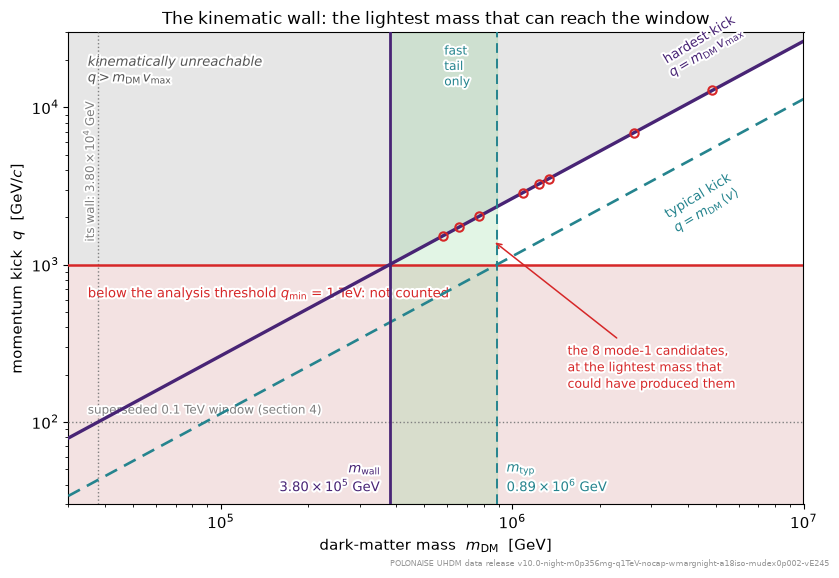

In [2]:
# --- the wall is hard: the cube's own mu is exactly zero below it -----------
print(f"m_wall = {M_WALL:.4e} GeV;  grid masses below it: "
      f"{int((MS_GRID < M_WALL).sum())} of {MS_GRID.size}")
for lam in LAMBDAS:
    below = rel.mass_plane("mu", mode=MODE, lam=lam, f_dm=F_DM,
                           atmosphere=True)[:, MS_GRID < M_WALL]
    print(f"  {lam:9s}: max stored mu over {below.size:4d} sub-wall cells = "
          f"{np.nanmax(below):.1e}")

# --- and from the modules, over eleven decades of coupling ------------------
A_WIDE = np.geomspace(1e-11, 1.0, 45)
print("\nrecomputed max_alpha mu(m) across alpha_n = 1e-11 .. 1 (bare halo):")
for m in (0.5 * M_WALL, 0.9 * M_WALL, 0.999 * M_WALL, 1.2 * M_WALL,
          2.0 * M_WALL):
    best = max(mu_of(m, a) for a in A_WIDE)
    print(f"  m = {m:.4e} GeV  ({m / M_WALL:5.3f} x m_wall):  "
          f"max mu = {best:.3e}")

# --- figure 1: the (mass, impulse) plane ------------------------------------
MS = np.geomspace(3e4, 1e7, 400)
Q_MIN_OLD = 100.0                       # the superseded 0.1 TeV window
M_WALL_OLD = Q_MIN_OLD / V_MAX

fig, ax = plt.subplots(figsize=(8.4, 5.8))
ax.set_xscale("log")
ax.set_yscale("log")
XLIM, YLIM = (3e4, 1e7), (3e1, 3e4)

# kinematically unreachable: no flyby of this mass delivers this much
ax.fill_between(MS, MS * V_MAX, YLIM[1], color="0.90", zorder=0)
halo_text(ax.text(3.5e4, 2.2e4, "kinematically unreachable\n"
                  r"$q > m_\mathrm{DM}\,v_\mathrm{max}$",
                  fontsize=9.5, color=C_GUIDE, style="italic", va="top"), 3.0)

# below the analysis threshold: nothing is counted
ax.fill_between(XLIM, YLIM[0], Q_MIN, color="#f3e2e2", zorder=0)
ax.axhline(Q_MIN, color=C_RED, lw=1.8, zorder=4)
halo_text(ax.text(3.5e4, Q_MIN * 0.62,
                  r"below the analysis threshold $q_\mathrm{min}$ = 1 TeV: "
                  "not counted", fontsize=9.5, color=C_RED), 3.0)

# the two kinematic lines
ax.plot(MS, MS * V_MAX, color=C_DARK, lw=2.4, zorder=5)
ax.plot(MS, MS * V_MEAN, color=C_MID, lw=1.9, ls=(0, (5, 3)), zorder=5)
halo_text(ax.text(4.5e6, 4.5e6 * V_MAX * 1.22,
                  "hardest kick\n"
                  r"$q = m_\mathrm{DM}\,v_\mathrm{max}$",
                  fontsize=9.5, color=C_DARK, ha="center", va="bottom",
                  linespacing=1.3, rotation=31), 3.0)
halo_text(ax.text(4.5e6, 4.5e6 * V_MEAN * 0.80,
                  "typical kick\n"
                  r"$q = m_\mathrm{DM}\,\langle v\rangle$",
                  fontsize=9.5, color=C_MID, ha="center", va="top",
                  linespacing=1.3, rotation=31), 3.0)

# the wall, and the tail-only onset band
ax.axvspan(M_WALL, M_TYP, color=C_LIGHT, alpha=0.17, zorder=1)
ax.axvline(M_WALL, color=C_DARK, lw=2.0, zorder=5)
ax.axvline(M_TYP, color=C_MID, lw=1.4, ls=(0, (5, 3)), zorder=5)
halo_text(ax.text(M_WALL * 0.93, 3.4e1,
                  f"$m_\\mathrm{{wall}}$\n${M_WALL / 1e5:.2f}\\times10^{{5}}$ GeV",
                  fontsize=9.5, color=C_DARK, ha="right", va="bottom"), 3.0)
halo_text(ax.text(M_TYP * 1.08, 3.4e1,
                  f"$m_\\mathrm{{typ}}$\n${M_TYP / 1e6:.2f}\\times10^{{6}}$ GeV",
                  fontsize=9.5, color=C_MID, ha="left", va="bottom"), 3.0)
halo_text(ax.text(5.85e5, 2.55e4, "fast\ntail\nonly", fontsize=8.8,
                  color=C_MID, ha="left", va="top"), 2.8)
# the eight candidates, each at the lightest mass that could have produced it
ax.plot(EVENTS / V_MAX, EVENTS, "o", ms=6, mfc="none", mec=C_RED, mew=1.5,
        zorder=6)
an = ax.annotate("the 8 mode-1 candidates,\nat the lightest mass that\n"
                 "could have produced them",
                 xy=(8.6e5, 1.42e3), xytext=(1.55e6, 1.55e2), fontsize=9,
                 color=C_RED, ha="left", va="bottom",
                 arrowprops=dict(arrowstyle="->", color=C_RED, lw=1.1))
halo_text(an, 3.0)

# the superseded window, for scale
ax.axhline(Q_MIN_OLD, color=C_GRAY, lw=1.0, ls=":", zorder=3)
ax.axvline(M_WALL_OLD, color=C_GRAY, lw=1.0, ls=":", zorder=3)
halo_text(ax.text(3.5e4, Q_MIN_OLD * 1.13,
                  "superseded 0.1 TeV window (section 4)",
                  fontsize=8.6, color=C_GRAY), 2.6)
halo_text(ax.text(M_WALL_OLD * 0.88, 1.4e3,
                  f"its wall: ${M_WALL_OLD / 1e4:.2f}\\times10^{{4}}$ GeV",
                  fontsize=8.6, color=C_GRAY, ha="left", va="bottom",
                  rotation=90), 2.6)

ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
ax.set_ylabel(r"momentum kick  $q$  [GeV/$c$]")
ax.set_title("The kinematic wall: the lightest mass that can reach the window")
fig.tight_layout()
save_figure(fig, "10_kinematic_wall")
plt.show()

## 2. Where the measured left edge sits

The wall is a statement about the *physics*; the contour is a statement about
the *grid*. The released mass axis is 119 logarithmic points from $10^{5}$ GeV
to the Planck mass, spaced by a factor 1.316, and the wall falls between two of
them: $3.953\times10^{5}$ (below) and $5.203\times10^{5}$ (above). So the
measured left edge cannot sit below the first grid mass above the wall, and on
all but one slice that is exactly where it sits:

* at $f_\mathrm{DM} = 1$ with the atmosphere, massless, 2 mm, 200 µm and 20 µm
  all start at $5.203\times10^{5}$ GeV, the first grid mass above the wall;
* at $f_\mathrm{DM} = 0.1$ without it the first three do the same, and the
  shortest range, 20 µm, starts one grid step later, at $6.849\times10^{5}$
  GeV. It is the weakest cross section on the axis, so at a tenth of the flux it
  is the first to lose the first column — one cell, a factor 1.316 in mass.

There is little free parameter left in the left edge. The onset is not where the
efficiency runs out or where the statistics get hard; it is $q_\mathrm{min}$
divided by $v_\mathrm{max}$, resolved to the width of one grid cell. Quoting the
edge as "$5.2\times10^{5}$ GeV" is quoting a grid point; quoting the wall,
$3.80\times10^{5}$ GeV, is quoting the analysis, and the refined boundary of
[`01_the_limit.ipynb`](01_the_limit.ipynb) puts the island's true tip at
$4.02\times10^{5}$ GeV.

The band drawn below is the released one, `alpha_lo`/`alpha_hi` from the
95% CL level set of the extremeness surface with each edge log-interpolated
between the bracketing coupling grid points — the same recipe the shipped reader
uses.

first excluded grid mass (m_wall = 3.7997e+05 GeV):
  f_DM = 1, atm        massless : 5.2030e+05 GeV = 1.369 x m_wall
  f_DM = 1, atm        2mm      : 5.2030e+05 GeV = 1.369 x m_wall
  f_DM = 1, atm        200um    : 5.2030e+05 GeV = 1.369 x m_wall
  f_DM = 1, atm        20um     : 5.2030e+05 GeV = 1.369 x m_wall
  f_DM = 0.1, no atm   massless : 5.2030e+05 GeV = 1.369 x m_wall
  f_DM = 0.1, no atm   2mm      : 5.2030e+05 GeV = 1.369 x m_wall
  f_DM = 0.1, no atm   200um    : 5.2030e+05 GeV = 1.369 x m_wall
  f_DM = 0.1, no atm   20um     : 6.8491e+05 GeV = 1.803 x m_wall

the wall is bracketed by grid masses 3.9526e+05 and 5.2030e+05 GeV
floor coupling at the first excluded mass: alpha_n = 2.060e-08 (f_DM = 1, atm), 2.067e-08 (f_DM = 0.1, no atm)
superseded 0.1 TeV capped scheme: left edge 3.0026e+05 GeV (pinned; that cube is not in release/)


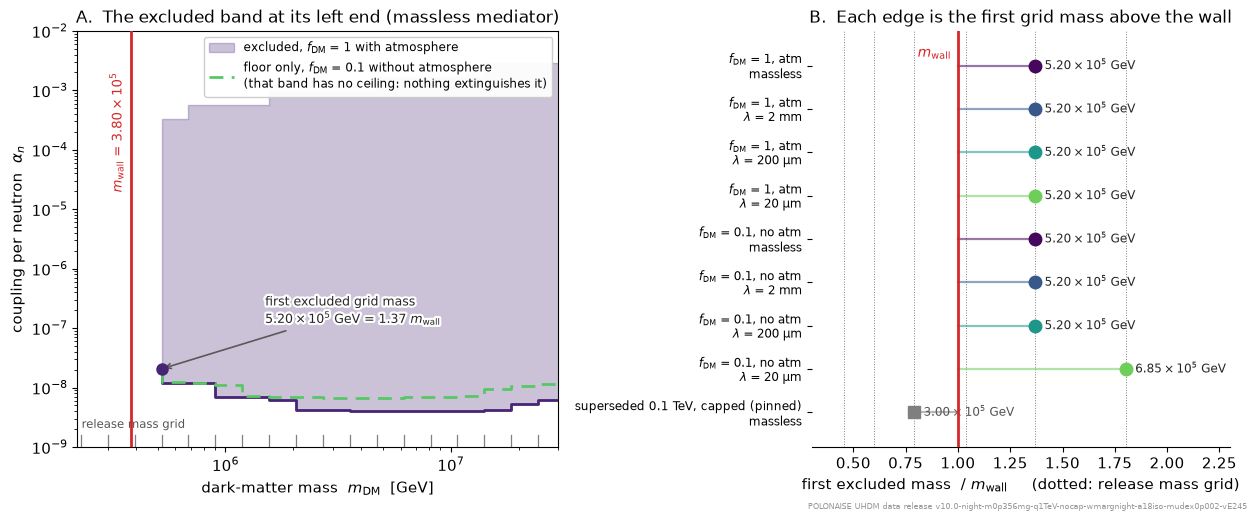

In [3]:
HYPOTHESES = (
    ("$f_\\mathrm{DM}$ = 1, atm", "f_DM = 1, atm", rel, 1.0, True),
    ("$f_\\mathrm{DM}$ = 0.1, no atm", "f_DM = 0.1, no atm", relB, 0.1, False),
)

rows = []
print(f"first excluded grid mass (m_wall = {M_WALL:.4e} GeV):")
for tag, plain, r, f_dm, atmo in HYPOTHESES:
    for lam in LAMBDAS:
        lo, _ = band_of(r, lam, f_dm, atmo)
        first = float(r.axes.mass_gev[np.where(np.isfinite(lo))[0][0]])
        rows.append((tag, lam, first))
        print(f"  {plain:20s} {lam:9s}: {first:.4e} GeV "
              f"= {first / M_WALL:.3f} x m_wall")

LO_A, HI_A = band_of(rel, "massless", 1.0, True)
LO_B, HI_B = band_of(relB, "massless", 0.1, False)
i_first = int(np.where(np.isfinite(LO_A))[0][0])
print(f"\nthe wall is bracketed by grid masses {MS_GRID[i_first - 1]:.4e} and "
      f"{MS_GRID[i_first]:.4e} GeV")
print(f"floor coupling at the first excluded mass: alpha_n = "
      f"{LO_A[i_first]:.3e} (f_DM = 1, atm), {LO_B[i_first]:.3e} "
      f"(f_DM = 0.1, no atm)")

# The section-4 ladder carries one historical row: M_EDGE_CAPPED, the left
# edge of the superseded 0.1 TeV, 10 cm-capped cube, pinned in the setup cell.
print(f"superseded 0.1 TeV capped scheme: left edge {M_EDGE_CAPPED:.4e} GeV "
      f"(pinned; that cube is not in release/)")

# --- figure 2: the band at the edge, and the ladder of measured edges -------
fig, (axA, axB) = plt.subplots(
    1, 2, figsize=(12.6, 5.2), gridspec_kw=dict(width_ratios=[1.15, 1]))

# --- A: the massless band, both files ---
axA.set_xscale("log")
axA.set_yscale("log")
ok = np.isfinite(LO_A)
axA.fill_between(MS_GRID[ok], LO_A[ok], HI_A[ok], color=C_DARK, alpha=0.28,
                 step="pre", zorder=3,
                 label="excluded, $f_\\mathrm{DM}$ = 1 with atmosphere")
axA.step(MS_GRID[ok], LO_A[ok], where="pre", color=C_DARK, lw=2.0, zorder=4)
okB = np.isfinite(LO_B)
axA.step(MS_GRID[okB], LO_B[okB], where="pre", color=C_LIGHT, lw=2.0,
         ls=(0, (5, 3)), zorder=4,
         label="floor only, $f_\\mathrm{DM}$ = 0.1 without atmosphere\n"
               "(that band has no ceiling: nothing extinguishes it)")
for m in MS_GRID[(MS_GRID > 2e5) & (MS_GRID < 3e7)]:
    axA.plot([m, m], [1e-9, 1.6e-9], color=C_GRAY, lw=0.9, zorder=2)
halo_text(axA.text(2.3e5, 2.1e-9, "release mass grid", fontsize=8.4,
                   color=C_GUIDE), 2.6)
axA.axvline(M_WALL, color=C_RED, lw=2.0, zorder=5)
halo_text(axA.text(M_WALL * 0.94, 2e-3,
                   f"$m_\\mathrm{{wall}}$ = ${M_WALL / 1e5:.2f}\\times10^{{5}}$",
                   fontsize=9.5, color=C_RED, ha="right", rotation=90,
                   va="top"), 3.0)
axA.plot([MS_GRID[i_first]], [LO_A[i_first]], "o", ms=8, color=C_DARK, zorder=6)
an = axA.annotate("first excluded grid mass\n"
                  f"${MS_GRID[i_first] / 1e5:.2f}\\times10^{{5}}$ GeV "
                  f"= {MS_GRID[i_first] / M_WALL:.2f} $m_\\mathrm{{wall}}$",
                  xy=(MS_GRID[i_first], LO_A[i_first]), xytext=(1.5e6, 2.0e-7),
                  fontsize=9, color="0.15", ha="left", va="center",
                  arrowprops=dict(arrowstyle="->", color="0.35", lw=1.2))
halo_text(an, 3.2)
axA.set_xlim(2.2e5, 3e7)
axA.set_ylim(1e-9, 1e-2)
axA.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
axA.set_ylabel(r"coupling per neutron  $\alpha_n$")
axA.set_title("A.  The excluded band at its left end (massless mediator)")
axA.legend(loc="upper right", fontsize=8.8, framealpha=0.95)

# --- B: the ladder of measured edges, in units of the wall ---
ladder = list(rows) + [("superseded 0.1 TeV, capped (pinned)", "massless",
                        M_EDGE_CAPPED)]
ys = np.arange(len(ladder))[::-1]
for k, (tag, lam, m) in enumerate(ladder):
    hist = tag.startswith("superseded")
    col = C_GRAY if hist else LAM_COL[lam]
    axB.plot([m / M_WALL], [ys[k]], "s" if hist else "o", ms=9, color=col,
             zorder=5)
    axB.plot([1.0, m / M_WALL], [ys[k]] * 2, color=col, lw=1.6, alpha=0.55,
             zorder=3)
    axB.text(m / M_WALL + 0.045, ys[k], f"{fmt_pow(m)} GeV", va="center",
             fontsize=8.6, color=C_GUIDE if hist else "0.15")
for m in MS_GRID[(MS_GRID > 1.5e5) & (MS_GRID < 2.6e6)]:
    axB.axvline(m / M_WALL, color=C_GRAY, lw=0.7, ls=":", zorder=1)
axB.axvline(1.0, color=C_RED, lw=2.0, zorder=4)
halo_text(axB.text(0.97, len(ladder) - 0.55, "$m_\\mathrm{wall}$", fontsize=10,
                   color=C_RED, ha="right", va="top"), 3.0)
axB.set_yticks(ys, [f"{t}\n{LAM_LABEL.get(l, l)}" for t, l, _ in ladder],
               fontsize=8.4)
axB.set_xlim(0.3, 2.3)
axB.set_ylim(-0.8, len(ladder) - 0.2)
axB.set_xlabel(r"first excluded mass  $/\ m_\mathrm{wall}$"
               "     (dotted: release mass grid)")
axB.set_title("B.  Each edge is the first grid mass above the wall")
for s in ("top", "right", "left"):
    axB.spines[s].set_visible(False)

fig.tight_layout()
save_figure(fig, "10_contour_left_edge")
plt.show()

## 3. The onset: the halo's velocity tail

The wall is a step in *support*, not a step in *sensitivity*. Immediately above
it the analysis is not suddenly healthy: a mass just past $m_\mathrm{wall}$ can
only be seen through halo particles moving between $q_\mathrm{min}/m_\mathrm{DM}$
and $v_\mathrm{esc}$, and that is a sliver of the distribution. The relevant
number is the fraction of the halo fast enough to matter,

$$\Phi(m_\mathrm{DM}) \;=\; \int_{q_\mathrm{min}/m_\mathrm{DM}}^{v_\mathrm{esc}}
f(v)\,dv ,$$

which is zero at the wall, $0.17\%$ at $1.1\,m_\mathrm{wall}$, $3.9\%$ at the
first excluded grid mass ($1.369\,m_\mathrm{wall}$) and $17\%$ at
$1.7\,m_\mathrm{wall}$, and passes one half only a little above
$m_\mathrm{typ} = 2.33\,m_\mathrm{wall}$ — the mass at which the *mean* halo
speed just reaches the threshold. Everything the contour does in its first
decade of mass is this factor turning on.

That softening shows up as a *coupling* price, but not the price a fixed
spectrum would charge. The exclusion needs $\mu \ge -\ln 0.05 = 3.0$ detected
kicks (the eight candidates all sit above $1.5\times10^{3}$ GeV, so at these
masses the whole spectrum lies in the candidate-free part of the window and the
optimum interval reduces to Poisson zero). Near the onset $\mu$ is far steeper
in the coupling than $\alpha_n^2$, because the spectrum does not end where
kinematics alone would put it. The closest approach the sensor radius allows
caps the impulse, so the spectrum ends at

$$q_\mathrm{end} \;=\; \min\!\big(m_\mathrm{DM}\,v_\mathrm{max},\;
\sqrt{2\,\alpha_n N_n\,m_\mathrm{DM}/R_\mathrm{eff}}\big),$$

and along the whole floor drawn below it is the second branch that binds: at
$1.369\,m_\mathrm{wall}$ it is 1098 GeV against a kinematic ceiling of 1369 GeV,
and at $11\,m_\mathrm{wall}$ it is 1509 GeV against 11 TeV. Raising $\alpha_n$
therefore scales the Rutherford cross section *and* pushes that endpoint further
up the turn-on, into higher efficiency. Measured on the refined grid,
$d\ln\mu/d\ln\alpha_n$ is 15 at $1.369\,m_\mathrm{wall}$ and 22 near
$1.7\,m_\mathrm{wall}$, not 2. Against the collapsing tail the net price is
mild: the released floor climbs by a factor 5.2, from $3.99\times10^{-9}$ at its
deepest point ($m_\mathrm{DM} = 8.1\times10^{6}$ GeV) to $2.06\times10^{-8}$ at
the first excluded grid mass, while $\Phi$ falls by a factor 26 across the same
interval. That factor of four, spread over a decade of mass, is the entire
"softness" of the present left edge.

**One numerical caveat, stated plainly.** The release evaluates $dR/dq$ on a
240-point logarithmic grid whose first step runs from 1000 to 1053.4 GeV. A mass
whose kinematic endpoint falls inside that first step has only one grid point in
its support, and the trapezoid returns zero — so *on the release grid* the
computable onset is $1.053\,m_\mathrm{wall}$, not $m_\mathrm{wall}$. Refining
the momentum grid tenfold moves that artefact down to $1.01\,m_\mathrm{wall}$,
and above $1.10\,m_\mathrm{wall}$ the two agree to a per cent or two — while at
$1.06\,m_\mathrm{wall}$, the first ratio the coarse grid can do at all, its
placement of the endpoint still costs 15%, as the two curves below show. Since
the release mass grid has no point below $1.369\,m_\mathrm{wall}$ anyway, the artefact never touches a
published cell; it is worth knowing about only if someone refines the mass axis
into the onset.

 m/m_wall     m [GeV]  tail frac  alpha_n(mu=3) rel grid   fine grid
    1.002  3.8073e+05  5.173e-07                     nan         nan
    1.010  3.8376e+05  1.322e-05                     nan   1.252e-06
    1.030  3.9136e+05  1.258e-04                     nan   2.302e-07
    1.060  4.0276e+05  5.465e-04               6.790e-08   7.946e-08
    1.100  4.1796e+05  1.690e-03               3.683e-08   3.690e-08
    1.160  4.4076e+05  5.027e-03               2.101e-08   2.134e-08
    1.369  5.2017e+05  3.891e-02               1.434e-08   1.430e-08
    1.400  5.3195e+05  4.740e-02               1.389e-08   1.388e-08
    1.700  6.4594e+05  1.690e-01               1.103e-08            
    2.330  8.8532e+05  4.815e-01               8.187e-09            
    3.000  1.1399e+06  7.029e-01               6.688e-09            
    4.500  1.7098e+06  8.982e-01               4.953e-09            
    7.000  2.6598e+06  9.714e-01               3.916e-09            
   11.000  4.1796e+06  9.925e-01  

                          2.330   8.19e-09      2330                   1083               20.9
                          4.500   4.95e-09      4500                   1170               12.2
                         11.000   3.37e-09     11000                   1509                6.4


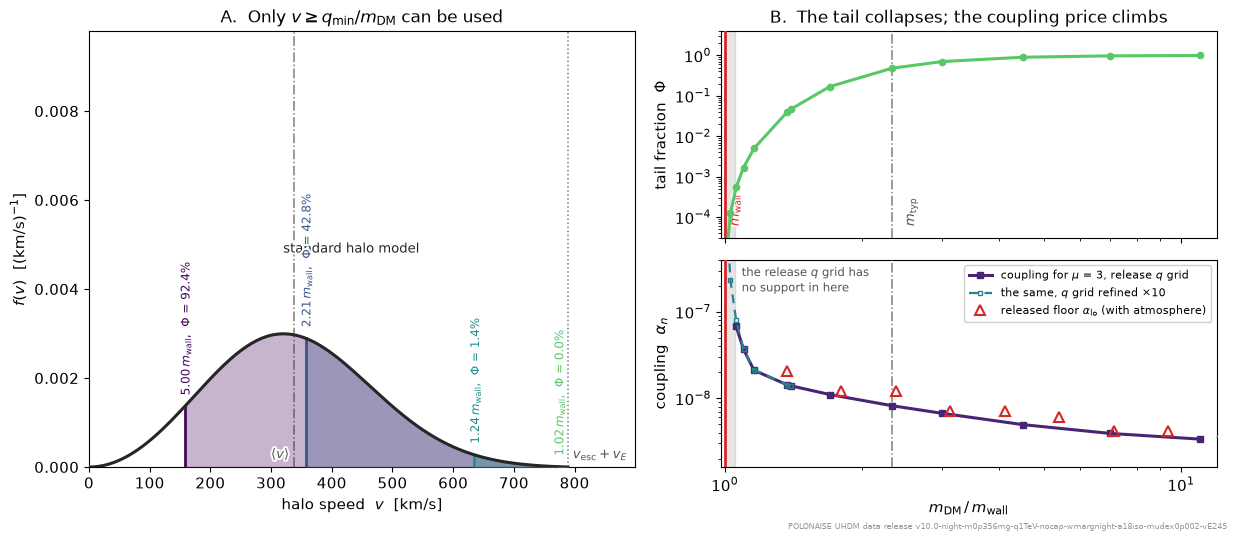

In [4]:
def tail_fraction(m):
    """Fraction of the halo fast enough to deliver q_min to a mass m."""
    v_min = Q_MIN / m
    if v_min >= V_MAX:
        return 0.0
    vv = np.linspace(v_min, V_MAX, 20_000)
    return float(np.trapezoid(halo.standard_halo_model(vv), vv))


def alpha_for_mu(m, qs, target=MU_REQ, lo=1e-11, hi=1e-2, n_iter=30):
    """Smallest coupling reaching `target` detected counts, by log bisection."""
    if mu_of(m, hi, qs=qs) < target:
        return np.nan
    for _ in range(n_iter):
        mid = np.sqrt(lo * hi)
        if mu_of(m, mid, qs=qs) < target:
            lo = mid
        else:
            hi = mid
    return float(np.sqrt(lo * hi))


def q_end_parts(m, alpha_n):
    """The two candidate spectrum endpoints [GeV]: the kinematic one,
    m v_max, and the sensor-radius one, sqrt(2 alpha_n N_n m / R_eff), which
    follows from asking for a speed that both delivers q and passes close
    enough to do so (q <= 2 alpha / (v R_eff)). The smaller one binds."""
    return m * V_MAX, float(np.sqrt(2.0 * alpha_n * N_N * m / (R_EFF * CONV)))


def mu_slope(m, alpha_n, h=1.03, qs=None):
    """Local d ln mu / d ln alpha_n, by a symmetric log-difference. Measured
    on the refined q grid, so it is the physics and not the grid spacing."""
    qs = QS_FINE if qs is None else qs
    mu_lo, mu_hi = mu_of(m, alpha_n / h, qs=qs), mu_of(m, alpha_n * h, qs=qs)
    if mu_lo <= 0.0 or mu_hi <= 0.0:
        return np.nan
    return float(np.log(mu_hi / mu_lo) / (2.0 * np.log(h)))


# the probe ratios span the onset; 1.369 is the first excluded grid mass in
# units of the wall and 2.33 is m_typ / m_wall, both in this release's frame
RATIOS = np.array([1.002, 1.01, 1.03, 1.06, 1.10, 1.16, 1.369, 1.4, 1.7, 2.33,
                   3.0, 4.5, 7.0, 11.0])
MS_ONSET = M_WALL * RATIOS
PHI = np.array([tail_fraction(m) for m in MS_ONSET])
A_REL = np.array([alpha_for_mu(m, QS) for m in MS_ONSET])
A_FINE = np.array([alpha_for_mu(m, QS_FINE) for m in MS_ONSET[:8]])

print(f"{'m/m_wall':>9} {'m [GeV]':>11} {'tail frac':>10} "
      f"{'alpha_n(mu=3) rel grid':>23} {'fine grid':>11}")
for i, r in enumerate(RATIOS):
    fine = f"{A_FINE[i]:.3e}" if i < A_FINE.size else ""
    print(f"{r:>9.3f} {MS_ONSET[i]:>11.4e} {PHI[i]:>10.3e} "
          f"{A_REL[i]:>23.3e} {fine:>11}")
print(f"\nreleased floor at the first excluded grid mass: "
      f"alpha_n = {LO_A[i_first]:.3e} (with atmosphere)")
print(f"deep floor over the whole mass range:          "
      f"alpha_n = {np.nanmin(LO_A):.3e} at m = "
      f"{MS_GRID[int(np.nanargmin(LO_A))]:.3e} GeV")
print(f"the floor climbs by a factor "
      f"{LO_A[i_first] / np.nanmin(LO_A):.2f} from its deepest point to the "
      f"first excluded grid mass, while the tail fraction falls by "
      f"{PHI[-1] / PHI[6]:.0f}")

# --- which endpoint binds at the floor, and how steep mu is there -----------
PICKS = [int(np.argmin(np.abs(RATIOS - r)))
         for r in (1.369, 1.7, 2.33, 4.5, 11.0)]
print(f"\n{'at the mu = 3 floor:':>21} {'m/m_wall':>9} {'alpha_n':>10} "
      f"{'m v_max':>9} {'sqrt(2 a N_n m/R_eff)':>22} {'dlnmu/dlnalpha_n':>18}")
for i in PICKS:
    q_kin, q_rad = q_end_parts(MS_ONSET[i], A_REL[i])
    print(f"{'':21} {RATIOS[i]:>9.3f} {A_REL[i]:>10.2e} {q_kin:>9.0f} "
          f"{q_rad:>22.0f} {mu_slope(MS_ONSET[i], A_REL[i]):>18.1f}")

# --- figure 3: the tail that carries the onset ------------------------------
fig, axd = plt.subplot_mosaic([["A", "B1"], ["A", "B2"]],
                              figsize=(12.4, 5.4),
                              gridspec_kw=dict(width_ratios=[1.1, 1]))
axA, axB1, axB2 = axd["A"], axd["B1"], axd["B2"]

# --- A: which part of f(v) each mass can use ---
vv = np.linspace(1e-6, V_MAX, 1200)
fv = halo.standard_halo_model(vv)
KMS = units.C_M_S / 1e3
SHOW = [5.0, 2.21, 1.243, 1.02]
cols = plt.cm.viridis(np.linspace(0.02, 0.74, len(SHOW)))
axA.plot(vv * KMS, fv / KMS, color="0.15", lw=2.2, zorder=6)
halo_text(axA.text(320, 0.00475, "standard halo model", fontsize=9.5,
                   color="0.15", ha="left", va="bottom"), 3.0)
for c, r in zip(cols, SHOW):
    m = M_WALL * r
    v_min = Q_MIN / m
    sel = vv >= v_min
    f_at = float(np.interp(v_min, vv, fv)) / KMS
    axA.fill_between(vv[sel] * KMS, fv[sel] / KMS, 0, color=c, alpha=0.30,
                     zorder=3)
    axA.plot([v_min * KMS] * 2, [0, f_at], color=c, lw=2.0, zorder=4)
    halo_text(axA.text(v_min * KMS - 7, f_at + 0.00025,
                       f"{r:.2f}$\\,m_\\mathrm{{wall}}$,  "
                       f"$\\Phi$ = {tail_fraction(m) * 100:.1f}%",
                       fontsize=8.6, color=c, ha="left", va="bottom",
                       rotation=90), 2.8)
axA.axvline(V_MEAN * KMS, color=C_GRAY, lw=1.1, ls="-.", zorder=2)
halo_text(axA.text(V_MEAN * KMS - 7, 0.0002, r"$\langle v\rangle$",
                   fontsize=9.5, color=C_GUIDE, ha="right"), 2.8)
axA.axvline(V_MAX * KMS, color=C_GRAY, lw=1.1, ls=":", zorder=2)
halo_text(axA.text(V_MAX * KMS + 8, 0.0002, r"$v_\mathrm{esc}+v_E$",
                   fontsize=9.5, color=C_GUIDE, ha="left"), 2.8)
axA.set_xlim(0, V_MAX * KMS * 1.14)
axA.set_ylim(0, 0.0098)
axA.set_xlabel(r"halo speed  $v$  [km/s]")
axA.set_ylabel(r"$f(v)$  [(km/s)$^{-1}$]")
axA.set_title("A.  Only $v \\geq q_\\mathrm{min}/m_\\mathrm{DM}$ can be used")

# --- B1: the tail fraction ---
axB1.set_xscale("log")
axB1.set_yscale("log")
axB1.plot(RATIOS, PHI, color=C_LIGHT, lw=2.2, marker="o", ms=4.5, zorder=4)
axB1.set_ylim(3e-5, 4.0)
axB1.set_ylabel(r"tail fraction  $\Phi$")
axB1.set_title("B.  The tail collapses; the coupling price climbs")
axB1.tick_params(labelbottom=False)

# --- B2: the coupling it costs ---
axB2.set_xscale("log")
axB2.set_yscale("log")
axB2.plot(RATIOS, A_REL, color=C_DARK, lw=2.2, marker="s", ms=4.5, zorder=5,
          label="coupling for $\\mu$ = 3, release $q$ grid")
axB2.plot(RATIOS[:A_FINE.size], A_FINE, color=C_MID, lw=1.6, ls=(0, (4, 3)),
          marker="s", ms=3.5, mfc="none", zorder=6,
          label="the same, $q$ grid refined $\\times$10")
sel = np.isfinite(LO_A) & (MS_GRID < 20 * M_WALL)
axB2.plot(MS_GRID[sel] / M_WALL, LO_A[sel], "^", ms=7, mfc="none", mec=C_RED,
          mew=1.5, ls="none", zorder=7,
          label="released floor $\\alpha_\\mathrm{lo}$ (with atmosphere)")
axB2.set_ylim(1.6e-9, 4e-7)
axB2.set_ylabel(r"coupling  $\alpha_n$")
axB2.set_xlabel(r"$m_\mathrm{DM}\,/\,m_\mathrm{wall}$")
axB2.legend(loc="upper right", fontsize=8.2, framealpha=0.95)

for a in (axB1, axB2):
    a.set_xlim(0.98, 12)
    a.axvline(1.0, color=C_RED, lw=2.0, zorder=3)
    a.axvline(M_TYP / M_WALL, color=C_GRAY, lw=1.1, ls="-.", zorder=3)
    a.axvspan(1.0, 1.0534, color=C_GRAY, alpha=0.20, zorder=1)
halo_text(axB1.text(1.02, 6e-5, "$m_\\mathrm{wall}$", fontsize=9.5,
                    color=C_RED, rotation=90, va="bottom"), 3.0)
halo_text(axB1.text(M_TYP / M_WALL * 1.06, 6e-5, "$m_\\mathrm{typ}$",
                    fontsize=9.5, color=C_GUIDE, rotation=90,
                    va="bottom"), 2.8)
halo_text(axB2.text(1.09, 3.4e-7, "the release $q$ grid has\n"
                    "no support in here",
                    fontsize=8.4, color=C_GUIDE, ha="left", va="top"), 3.0)

fig.tight_layout()
save_figure(fig, "10_halo_tail_onset")
plt.show()

## 4. Retrospective: why the 0.1 TeV window had a soft edge

With the window starting at 0.1 TeV the wall was at
$q_\mathrm{min}/v_\mathrm{max} = 3.8\times10^{4}$ GeV, an order of magnitude
below anything the contour reached, so it never bound anything. What bound the
contour instead was the *measured efficiency*, and it bound it softly.

The mode-1 efficiency reaches 50% at $q_{50} = 1209$ GeV and below that it does
not taper, it collapses — 19 decades of $\varepsilon$ across the single decade
of $q$ between 100 GeV and 1 TeV. Under the old window the analysis was free to
count kicks anywhere on that cliff, at whatever efficiency they carried. So the
left edge was decided by an arithmetic question rather than a kinematic one: can
the coupling buy back the efficiency penalty at the highest rung a given mass
can reach?

It could, but not by the route one might guess, and the cell below measures
which. Raising the coupling does two things at once: the cross section grows as
$\alpha^2$, *and* the spectrum's own endpoint stretches, because the hardest
kick a flyby can deliver is set by the closest approach the sensor radius
allows,
$q_\mathrm{end} = \min\!\big(m\,v_\mathrm{max},\ \sqrt{2\,\alpha_n N_n\,m/R_\mathrm{eff}}\big)$,
which climbs as $\sqrt{\alpha}$ — up the cliff. Wherever the second branch is
the binding one, $\mu$ is far steeper in the coupling than $\alpha^2$: measured
at $m = 3.0\times10^{5}$ GeV in the superseded scheme, the local exponent
$d\ln\mu/d\ln\alpha_n$ peaks near 14 and is still above 13 at
$\alpha_n \approx 4\times10^{-9}$. But that stretch is over quickly. Above
$\alpha_n \approx 10^{-8}$ the sensor-radius endpoint has overtaken the
kinematic one, $q_\mathrm{end}$ is pinned at $m\,v_\mathrm{max}$ = 790 GeV, and
the exponent falls back to exactly 2. So the old edge was bought the slow way:
decades of $\alpha^2$ against a *fixed* efficiency penalty of
$\varepsilon(790\ \mathrm{GeV}) \approx 1\times10^{-2}$, reaching $\mu = 3$ only
at $\alpha_n \approx 7\times10^{-8}$ — and then turning over, because at
larger coupling the capped cross section's projection ceiling took the rate away
again. The steep regime itself has not gone anywhere; it has moved to where the
floor now is. Section 3 measures the same mechanism at 15 and 22 along the
present floor, where the sensor-radius endpoint *is* the binding one. The capped
cube's contour reached down to $3.0\times10^{5}$ GeV, roughly
$0.79\,m_\mathrm{wall}$ in today's units, and it would have kept creeping lower
had the mass grid gone lower — there was no place it had to stop.

What changed is not the steepness but where the window starts. Setting
$q_\mathrm{min}$ = 1 TeV lifts the window edge 19 decades up the mode-1 turn-on,
from $\varepsilon = 1\times10^{-20}$ at 100 GeV to $\varepsilon = 0.17$ at
1 TeV. That edge is a stated momentum threshold, not a feature of the turn-on —
it still sits below the 50% point at 1209 GeV. And the same factor of ten lifts
the wall, to $3.80\times10^{5}$ GeV, which is *above* where the old soft edge
sat. It is the wall, not the efficiency, that now decides where the contour
stops.

The panel below makes the contrast concrete at that mass, $3.0\times10^{5}$
GeV — the left edge of the superseded contour — and the cell prints the local
exponent along the way, so the two regimes can be read off rather than taken on
trust. Under the 1 TeV window the same mass returns $\mu = 0$ at every coupling;
there is nothing to buy. Both curves are recomputed here for the bare halo — the old one with the 0.1 TeV window and the 10 cm
impact-parameter cap the earlier cross section carried, the new one with
neither — but both use the efficiency table shipped with this release, so the
old curve shows the mechanism rather than reproducing that analysis.

mode-1 efficiency: eps(100 GeV) = 1.06e-20   eps(300) = 1.46e-12   eps(700) = 2.04e-03
                     q_50 = 1209 GeV   eps(1000) = 0.173   (19.2 decades of eps between the two window edges)

old window: wall at 3.800e+04 GeV; 1 TeV window: wall at 3.800e+05 GeV (x10)
demonstration mass m = 3.0026e+05 GeV = 0.790 x the 1 TeV wall
  0.1 TeV window, 10 cm cap : max mu = 7.445e+03  (crosses 3 at alpha_n ~ 6.7e-08)
  1 TeV window, uncapped    : max mu = 0.000e+00

  local exponent d ln mu / d ln alpha_n at m = 3.003e+05 GeV (0.1 TeV window, 10 cm cap):
    alpha_n = 2.64e-09: mu = 5.29e-09, slope =  13.6, q_end =   358 GeV (sensor radius), eps = 1.53e-10
    alpha_n = 3.65e-09: mu = 4.94e-07, slope =  13.2, q_end =   421 GeV (sensor radius), eps = 1.25e-08
    alpha_n = 9.62e-09: mu = 2.55e-02, slope =   6.9, q_end =   684 GeV (sensor radius), eps = 1.34e-03
    alpha_n = 9.25e-08: mu = 7.18e+00, slope =   2.0, q_end =   790 GeV (kinematic), eps = 1.40e-02
    alpha_n = 6.69e-08: mu 

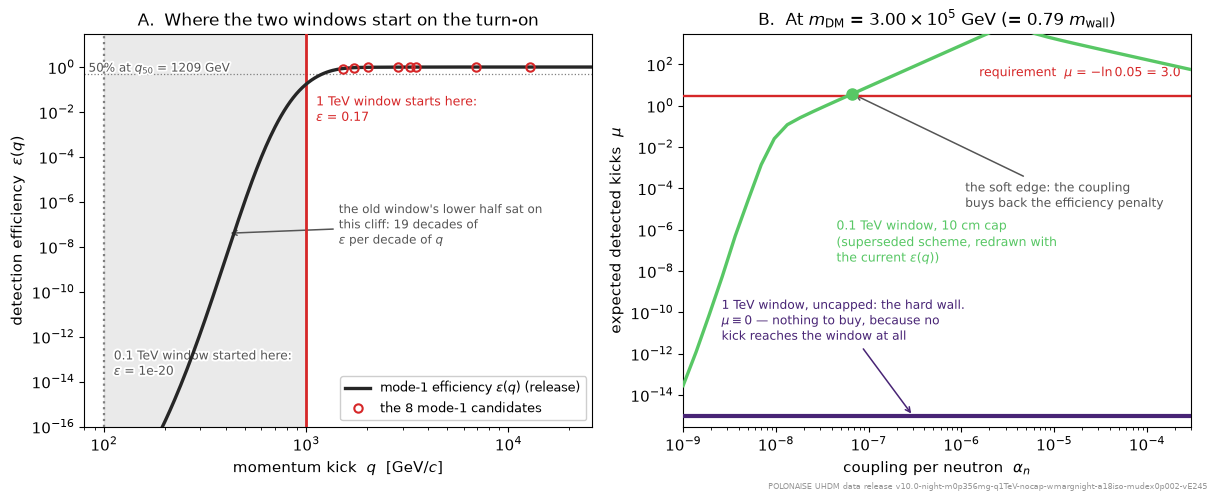

In [5]:
# Q_MIN_OLD / M_WALL_OLD were set alongside figure 1. This retrospective
# reinstates the two ingredients of the superseded scheme that are inspectable
# from here -- the 0.1 TeV window and the 10 cm impact-parameter cap in the
# cross section -- but it folds in the efficiency table the package carries
# today. It shows the mechanism; it is not a re-run of that analysis.
QS_OLD = np.geomspace(Q_MIN_OLD, 3e4 * 8.4e3, 240)   # the old build's q grid
B_CAP_OLD = 0.1                                       # the old cross-section cap
# the superseded cube predates the projection-kernel flag and was built in the
# planar-signed convention, so that convention is named here rather than
# inherited from the open file (which is isotropic-folded)
XS_OLD = rate.make_xsec(None, b_constrained_max=B_CAP_OLD,
                        projection_kernel=release.KERNEL_PRE_FLAG)

M_DEMO = float(MS_GRID[int(np.argmin(np.abs(MS_GRID - 3.0e5)))])
A_DEMO = np.geomspace(1e-9, 3e-4, 40)
MU_OLD = np.array([mu_of(M_DEMO, a, qs=QS_OLD, xs=XS_OLD) for a in A_DEMO])
MU_NEW = np.array([mu_of(M_DEMO, a, qs=QS, xs=XS) for a in A_DEMO])

DECADES = float(np.log10(float(eps1(Q_MIN)) / float(eps1(Q_MIN_OLD))))
print(f"mode-{MODE} efficiency: eps(100 GeV) = {float(eps1(100)):.2e}   "
      f"eps(300) = {float(eps1(300)):.2e}   eps(700) = {float(eps1(700)):.2e}")
print(f"                     q_50 = {Q50:.0f} GeV   "
      f"eps(1000) = {float(eps1(1000)):.3f}   "
      f"({DECADES:.1f} decades of eps between the two window edges)")
print(f"\nold window: wall at {M_WALL_OLD:.3e} GeV; "
      f"1 TeV window: wall at {M_WALL:.3e} GeV (x{M_WALL / M_WALL_OLD:.0f})")
print(f"demonstration mass m = {M_DEMO:.4e} GeV "
      f"= {M_DEMO / M_WALL:.3f} x the 1 TeV wall")
print(f"  0.1 TeV window, 10 cm cap : max mu = {MU_OLD.max():.3e}  "
      f"(crosses 3 at alpha_n ~ "
      f"{A_DEMO[int(np.argmax(MU_OLD >= MU_REQ))]:.1e})")
print(f"  1 TeV window, uncapped    : max mu = {MU_NEW.max():.3e}")

# the local exponent d ln mu / d ln alpha_n along the old-scheme curve: the
# steep stretch, where the sensor-radius endpoint is still climbing the cliff,
# and the alpha^2 stretch beyond it, where it is pinned at m v_esc
_ok = MU_OLD > 0
_sl = np.gradient(np.log(MU_OLD[_ok]), np.log(A_DEMO[_ok]))
_i_pk = int(np.argmax(_sl))
_i_cross = int(np.argmax(MU_OLD >= MU_REQ))
print(f"\n  local exponent d ln mu / d ln alpha_n at m = {M_DEMO:.3e} GeV "
      f"(0.1 TeV window, 10 cm cap):")
for _a in (2.5e-9, 4e-9, 1e-8, 1e-7, A_DEMO[_i_cross]):
    _j = int(np.argmin(np.abs(A_DEMO[_ok] - _a)))
    _q_kin, _q_rad = M_DEMO * V_MAX, float(np.sqrt(2 * A_DEMO[_ok][_j] * N_N
                                                  * M_DEMO / (R_EFF * CONV)))
    _bind = "sensor radius" if _q_rad < _q_kin else "kinematic"
    print(f"    alpha_n = {A_DEMO[_ok][_j]:.2e}: mu = {MU_OLD[_ok][_j]:.2e}, "
          f"slope = {_sl[_j]:5.1f}, q_end = {min(_q_kin, _q_rad):5.0f} GeV "
          f"({_bind}), eps = {float(eps1(min(_q_kin, _q_rad))):.2e}")
print(f"  peak slope {_sl[_i_pk]:.1f} at alpha_n = {A_DEMO[_ok][_i_pk]:.2e}, "
      f"where mu = {MU_OLD[_ok][_i_pk]:.1e} -- twelve decades below the "
      f"requirement")
print(f"  at the mu = 3 crossing (alpha_n = {A_DEMO[_i_cross]:.2e}) the slope "
      f"is {_sl[list(np.where(_ok)[0]).index(_i_cross)]:.2f}: plain alpha^2")
# the two regimes are the point of the paragraph above; pin them
assert _sl[_i_pk] > 10.0, "the steep stretch is gone"
assert abs(_sl[list(np.where(_ok)[0]).index(_i_cross)] - 2.0) < 0.2, \
    "the mu = 3 crossing is no longer in the alpha^2 regime"
print("  (both recomputed with the efficiency table shipped with this "
      "release, not the one the capped build used)")

# --- figure 4: the soft edge and the hard one -------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.2, 5.0))

# --- A: the efficiency, and where each window starts ---
axA.set_xscale("log")
axA.set_yscale("log")
axA.plot(q_tab, e_tab, color="0.15", lw=2.4, zorder=5,
         label=f"mode-{MODE} efficiency $\\varepsilon(q)$ (release)")
axA.axvspan(Q_MIN_OLD, Q_MIN, color=C_GRAY, alpha=0.16, zorder=1)
axA.axvline(Q_MIN_OLD, color=C_GRAY, lw=1.6, ls=":", zorder=4)
axA.axvline(Q_MIN, color=C_RED, lw=2.0, zorder=4)
halo_text(axA.text(Q_MIN_OLD * 1.12, 2e-14,
                   "0.1 TeV window started here:\n"
                   f"$\\varepsilon$ = {float(eps1(Q_MIN_OLD)):.0e}",
                   fontsize=8.8, color=C_GUIDE), 2.8)
halo_text(axA.text(Q_MIN * 1.12, 4e-3,
                   "1 TeV window starts here:\n"
                   f"$\\varepsilon$ = {float(eps1(Q_MIN)):.2f}",
                   fontsize=9, color=C_RED), 3.0)
axA.axhline(0.5, color=C_GRAY, lw=0.9, ls=":", zorder=2)
halo_text(axA.text(84, 0.62, f"50% at $q_{{50}}$ = {Q50:.0f} GeV",
                   fontsize=8.6, color=C_GUIDE), 2.6)
axA.plot(EVENTS, eps1(EVENTS), "o", ms=6, mfc="none", mec=C_RED, mew=1.5,
         zorder=6, label=f"the 8 mode-{MODE} candidates")
an = axA.annotate("the old window's lower half sat on\n"
                  f"this cliff: {DECADES:.0f} decades of\n"
                  "$\\varepsilon$ per decade of $q$",
                  xy=(4.1e2, 4e-8), xytext=(1.45e3, 1.0e-6), fontsize=8.6,
                  color=C_GUIDE, ha="left", va="top",
                  arrowprops=dict(arrowstyle="->", color=C_GUIDE, lw=1.1))
halo_text(an, 3.0)
axA.set_xlim(80, 2.6e4)
axA.set_ylim(1e-16, 30)
axA.set_xlabel(r"momentum kick  $q$  [GeV/$c$]")
axA.set_ylabel(r"detection efficiency  $\varepsilon(q)$")
axA.set_title("A.  Where the two windows start on the turn-on")
axA.legend(loc="lower right", fontsize=9, framealpha=0.95)

# --- B: what a sub-wall mass can buy, then and now ---
axB.set_xscale("log")
axB.set_yscale("log")
axB.plot(A_DEMO, np.maximum(MU_OLD, 1e-16), color=C_LIGHT, lw=2.4, zorder=5)
axB.plot(A_DEMO, np.full_like(A_DEMO, 1e-15), color=C_DARK, lw=3.0, zorder=6)
halo_text(axB.text(4.5e-8, 4e-6, "0.1 TeV window, 10 cm cap\n"
                   "(superseded scheme, redrawn with\n"
                   "the current $\\varepsilon(q)$)", fontsize=9, color=C_LIGHT,
                   ha="left", va="top"), 3.0)
axB.axhline(MU_REQ, color=C_RED, lw=1.7, zorder=4)
halo_text(axB.text(2.4e-4, MU_REQ * 9,
                   "requirement  $\\mu$ = $-\\ln 0.05$ = 3.0", fontsize=9,
                   color=C_RED, ha="right"), 3.0)
i_cross = int(np.argmax(MU_OLD >= MU_REQ))
axB.plot([A_DEMO[i_cross]], [MU_OLD[i_cross]], "o", ms=8, color=C_LIGHT,
         zorder=7)
an = axB.annotate("the soft edge: the coupling\nbuys back the efficiency penalty",
                  xy=(A_DEMO[i_cross], MU_OLD[i_cross]),
                  xytext=(1.1e-6, 2.5e-4), fontsize=8.8, color=C_GUIDE,
                  ha="left", va="top",
                  arrowprops=dict(arrowstyle="->", color=C_GUIDE, lw=1.1))
halo_text(an, 3.0)
an = axB.annotate("1 TeV window, uncapped: the hard wall.\n"
                  "$\\mu \\equiv 0$ — nothing to buy, because no\n"
                  "kick reaches the window at all",
                  xy=(3e-7, 1e-15), xytext=(2.6e-9, 3e-12), fontsize=8.8,
                  color=C_DARK, ha="left", va="bottom",
                  arrowprops=dict(arrowstyle="->", color=C_DARK, lw=1.1))
halo_text(an, 3.0)
axB.set_xlim(A_DEMO[0], A_DEMO[-1])
axB.set_ylim(3e-16, 3e3)
axB.set_xlabel(r"coupling per neutron  $\alpha_n$")
axB.set_ylabel(r"expected detected kicks  $\mu$")
axB.set_title(f"B.  At $m_\\mathrm{{DM}}$ = "
              f"${M_DEMO / 1e5:.2f}\\times10^{{5}}$ GeV "
              f"(= {M_DEMO / M_WALL:.2f} $m_\\mathrm{{wall}}$)")

fig.tight_layout()
save_figure(fig, "10_soft_vs_hard_edge")
plt.show()

## 5. Between the edges: transit-count and reach maps

*Everything in this section is pedagogical; none of it feeds the limit.* Before
the right edge, the whole region on one plane. Every edge of the excluded region
has a one-line explanation (scalings at fixed exposure):

- **Left edge (kinematic wall).** Below
  $m = q_\text{th}/v_\text{max} = 3.80\times10^{5}$ GeV even the fastest halo
  particle cannot deliver the threshold kick, at any coupling
  ($q_\text{th}$ = 1 TeV/$c$, $v_\text{max} = v_\text{esc} + v_E =
  2.6\times10^{-3}$). Sections 1–4.
  It is hard, and on this grid the first excluded mass, $5.20\times10^{5}$ GeV,
  is the first grid point above it.
- **Bottom edge (statistics floor).** The smallest coupling with $\mu \gtrsim 3$
  expected events. The rate scales as $\alpha^2 n_\text{DM} \propto \alpha^2/m$,
  so the floor rises as $\alpha_\text{min} \propto \sqrt{m}$. Ranges with
  $\lambda \gtrsim$ mm share the same floor (Coulomb regime); shorter ranges pay
  the momentum-cap penalty, $\tilde q_\text{max} = K_1(\xi)$.
- **Top edge (atmospheric ceiling), where there is one.** Stopping power also
  scales as $\alpha^2/m$: above the ceiling particles arrive below threshold
  speed, so the ceiling rises $\propto \sqrt{m}$ (up to a Coulomb log). It
  meets the top of the scanned coupling grid part way along the massless
  contour, and beyond that the band is open at the top: an edge drawn at
  $\alpha_n = 1$ is where the scan stopped, not where the physics closed.
- **Right edge, finite range (reach saturation).** Once the impact parameters
  needed for a kick exceed $\lambda$, the reach grows only as
  $\lambda\ln\alpha$, the cross section saturates at $\sim\lambda^2$, and the
  falling number density $1/m$ wins: each factor of 10 in $\lambda$ buys roughly
  a factor of 100 in mass reach. No finite range reaches the Planck mass. This
  edge is in the surface itself.
- **Right edge, massless (the flux cut).** An exactly massless mediator has
  Coulomb reach $\propto \alpha$, and this release does **not** truncate the
  impact-parameter integral, so nothing in the surface closes the band: the
  massless contour runs to the Planck mass. What closes it is the statement made
  *after* the calculation that sections 6–9 make quantitative. The maps below
  are where it can be read off: it is the $N_t$ contour of the *aperture*, not
  of the reach.

### The maps

Sliced from the `/halo` group of the data release. They are stored once at the
build-side baseline $f_\mathrm{DM}$ = 0.1 with no fraction axis, so their
transit counts are a factor of ten below the `/results` ones; that is fine here,
because the region's *shape* is independent of $f_\mathrm{DM}$ up to a flux
rescaling.

**Top row:** color is $\log_{10} N_t$, the expected number of particles passing
within $\pi b_\text{max}^2$ during the exposure (halo flux, no attenuation;
the atmosphere only matters near the low-mass ceiling). White contours mark
decades of $N_t$ (the $N_t = 1$ line is drawn heavier); red: the 95% exclusion
contour from the scan. The
finite-range $N_t = 1$ boundary is a near-vertical wall (saturating reach);
the massless mediator's boundary follows a $\sqrt{m}$ diagonal and keeps going,
because with no cap on the impact-parameter integral the reach keeps growing
with coupling. Nothing in these maps stands it up into a wall — that is the
point, and it is why the release states the flux cut separately.

**Bottom row:** the flux-averaged threshold reach
$b_\text{max} = \sqrt{\langle b^2 \rangle}$ in meters, with contours at
everyday length scales and the same red 95% exclusion contour overlaid, so
the reach along the sensitivity boundary can be read off directly. This is the
aperture that converts flux into transits,
$N_t = \Phi \cdot \pi b_\text{max}^2 \cdot T$: for the massless mediator the
*formal* reach at large coupling is macroscopic
($b_\text{max} = 2\alpha/(q_\text{th} v)$), and this release does not cap it, so
the massless reach map runs off to macroscopic values at strong coupling; the
finite-range reach saturates near $R_\text{eff} + \mathcal{O}(10)\lambda$,
which is why its $N_t = 1$ wall is real.

**This is what the flux cut is for.** Rather than truncating the integral, the
release evaluates the same arithmetic once, at a fixed 10 cm aperture, and
states the mass where it runs out:
$N(m) = f_\mathrm{DM}\,\rho_0\,\langle v\rangle\,\pi b_\text{cap}^2\,T / m$, so
$m_\text{cut} \approx 2.5\times10^{14}\ \text{GeV} \times
(f_\mathrm{DM}/0.1)\,(b_\text{cap}/10\,\text{cm})^2\,(T/220\,\text{h})\,
(1/N_\text{req})$, evaluated at the 219.66 h analysis live-time. At
$N_\text{req} = 3$ — **an assumption of the release, not a measurement** — that
is $8.40\times10^{13}$ GeV at $f_\mathrm{DM}$ = 0.1 and $8.40\times10^{14}$ GeV
at $f_\mathrm{DM}$ = 1. Section 6 draws that curve; sections 7–9 read it against
the surfaces.

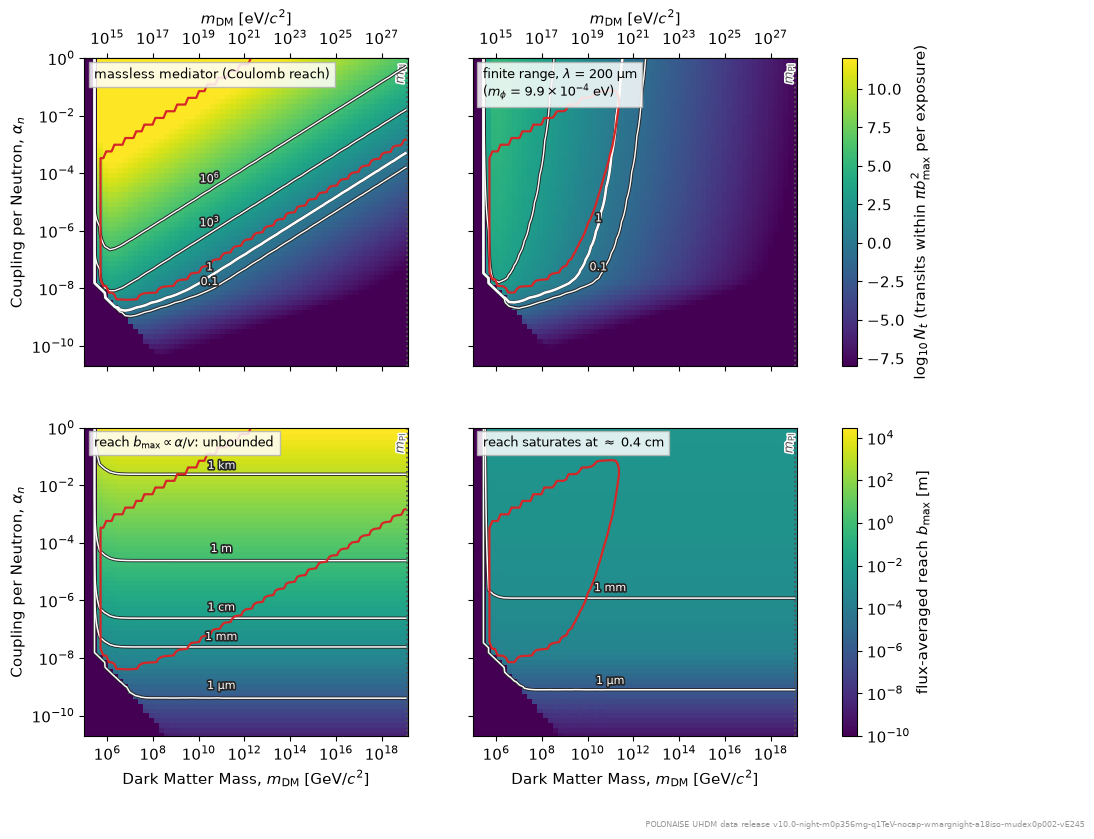

In [6]:
# transit-count and reach maps, sliced from the /halo group of the data release
from matplotlib.colors import LogNorm, Normalize

# the two exclusion planes overlaid below: the massless (Coulomb) scan and
# the finite reference-range (200 um) scan, from the f_DM = 1 file
P_ML = rel.mass_plane("extremeness", MODE, "massless", f_dm=F_DM)
P_REF = rel.mass_plane("extremeness", MODE, "200um", f_dm=F_DM)
ms_map, al_map = rel.axes_halo.mass_gev, rel.axes_halo.alpha_n
NT_ML_MAP = rel.mass_plane("n_transit", lam="massless", group="halo")
B_ML_MAP = rel.mass_plane("bmax", lam="massless", group="halo")
NT_FR_MAP = rel.mass_plane("n_transit", lam="200um", group="halo")
B_FR_MAP = rel.mass_plane("bmax", lam="200um", group="halo")

def outline(artists):  # keep white lines/labels legible on any viridis shade
    for a in artists:
        a.set_path_effects([pe.Stroke(linewidth=2.4, foreground="0.15"),
                            pe.Normal()])

def label_levels(ax, X_MAP, levels, names, m_ref=1e11):
    # label each level just above its line, mid-plot (the lines are close to
    # horizontal away from the kinematic floor)
    col = np.argmin(np.abs(ms_map - m_ref))
    for lev in levels:
        with np.errstate(divide="ignore"):
            miss = np.abs(np.log10(np.where(X_MAP[:, col] > 0,
                                            X_MAP[:, col], np.nan) / lev))
        if np.nanmin(miss) < 0.3:
            y = al_map[np.nanargmin(miss)]
            txt = ax.text(m_ref, y * 1.5, names[lev], fontsize=8, color="w",
                          ha="center", va="bottom")
            outline([txt])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.8), sharex=True, sharey=True)
norm_nt = Normalize(vmin=-8, vmax=12)
norm_b = LogNorm(vmin=1e-10, vmax=3e4)
NT_LEVELS = [0.1, 1.0, 1e3, 1e6]
NT_NAMES = {0.1: "0.1", 1.0: "1", 1e3: "$10^3$", 1e6: "$10^6$"}
B_LEVELS = [1e-6, 1e-3, 1e-2, 1.0, 1e3]
B_NAMES = {1e-6: "1 µm", 1e-3: "1 mm", 1e-2: "1 cm", 1.0: "1 m", 1e3: "1 km"}
titles = ["massless mediator (Coulomb reach)",
          "finite range, " + lamb_label(LAMB_REF) + "\n(" +
          mphi_label(LAMB_REF) + ")"]

for j, (NT_MAP, B_MAP) in enumerate([(NT_ML_MAP, B_ML_MAP),
                                     (NT_FR_MAP, B_FR_MAP)]):
    ax = axes[0, j]
    z = np.log10(np.clip(NT_MAP, 1e-8, 1e12))
    mesh_nt = ax.pcolormesh(ms_map, al_map, z, cmap="viridis", norm=norm_nt,
                            shading="auto")
    cs = ax.contour(ms_map, al_map, NT_MAP, levels=NT_LEVELS, colors="w",
                    linewidths=[1.0 if lev != 1.0 else 1.9
                                for lev in NT_LEVELS])
    outline(getattr(cs, "collections", [cs]))
    label_levels(ax, NT_MAP, NT_LEVELS, NT_NAMES, m_ref=3e10)
    ax.text(0.03, 0.97, titles[j], transform=ax.transAxes, ha="left",
            va="top", fontsize=9, bbox=dict(fc="white", ec="0.7", alpha=0.85))

    ax = axes[1, j]
    mesh_b = ax.pcolormesh(ms_map, al_map, np.clip(B_MAP, 1e-10, None),
                           cmap="viridis", norm=norm_b, shading="auto")
    cs = ax.contour(ms_map, al_map, B_MAP, levels=B_LEVELS, colors="w",
                    linewidths=1.1)
    outline(getattr(cs, "collections", [cs]))
    label_levels(ax, B_MAP, B_LEVELS, B_NAMES)
    _cap = rel.b_constrained_max          # None if the cube is uncapped
    note = ((r"reach $b_{\rm max} \propto \alpha/v$" +
             (rf", capped at {_cap * 100:.0f} cm" if _cap else ": unbounded"))
            if j == 0 else
            rf"reach saturates at $\approx$ {B_MAP.max() * 100:.1f} cm")
    ax.text(0.03, 0.97, note, transform=ax.transAxes, ha="left",
            va="top", fontsize=9, bbox=dict(fc="white", ec="0.7", alpha=0.85))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")

# overlay each column's own 95% exclusion: the massless (Coulomb) scan on the
# massless panels, the finite reference-range scan on the finite-range panels
COL_SCAN = [dict(ms=rel.axes.mass_gev, alphas_n=rel.axes.alpha_n, extremeness=P_ML),
            dict(ms=rel.axes.mass_gev, alphas_n=rel.axes.alpha_n, extremeness=P_REF)]   # j=0 massless, j=1 finite (200um)
for i in (0, 1):
    for j in (0, 1):
        s = COL_SCAN[j]
        if s is None:
            continue
        axes[i, j].contour(s["ms"], s["alphas_n"], s["extremeness"],
                           levels=[CONFIDENCE], colors="#d62728",
                           linewidths=1.6)

# the mass grid stops at the Planck mass: mark that endpoint (label inside)
_m_pl = ms_map[-1]
for ax in axes.ravel():
    ax.axvline(_m_pl, color="#555555", lw=1.3, ls=":", zorder=1)
    _t = ax.text(_m_pl, 0.985, r"$m_{\mathrm{Pl}}$", color="#555555",
                 fontsize=9, ha="right", va="top", rotation=90,
                 zorder=1.5,   # under contour lines: halo must not notch them
                 transform=ax.get_xaxis_transform())
    _t.set_path_effects([pe.Stroke(linewidth=2.2, foreground="w"), pe.Normal()])

for ax in axes[:, 0]:
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
axes[0, 0].set_ylim(al_map[0], 1.0)
for j in (0, 1):
    sec = axes[0, j].secondary_xaxis(
        "top", functions=(lambda x: x * 1e9, lambda x: x / 1e9))
    sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
fig.colorbar(mesh_nt, ax=axes[0, :], label=r"$\log_{10} N_t$ (transits within "
                                           r"$\pi b_{\rm max}^2$ per exposure)")
fig.colorbar(mesh_b, ax=axes[1, :],
             label=r"flux-averaged reach $b_{\rm max}$ [m]")
save_figure(fig, "03_transit_reach_maps", bbox_inches="tight")
plt.show()

## 6. The transit curve

$N(m_\mathrm{DM})$ is a straight line of slope $-1$ on log axes, and every
number in it is fixed before any detector physics enters: the local density, the
mean halo speed, the live-time, and the choice of aperture. Reading it off:

| $m_\mathrm{DM}$ [GeV] | $N$ at $f_\mathrm{DM}=1$ | mean interval between transits |
|---|---|---|
| $10^{8}$ | $2.5\times10^{7}$ | 31 ms |
| $10^{12}$ | $2.5\times10^{3}$ | 5.2 min |
| $2.70\times10^{14}$ | 9.35 | 23 h |
| $8.40\times10^{14}$ | 3.0 | 73 h |
| $1.22\times10^{19}$ | $2.1\times10^{-4}$ | 121 yr |

At $10^{8}$ GeV the halo delivers tens of millions of close passages during the
exposure and the limit is entirely a question of how hard each one kicks. Six
decades of mass later the exposure contains a handful of passages, and one more
decade after that it contains none: at the Planck mass the sensor would have to
sit still for a century and a quarter to expect a single flyby within 10 cm.

Where to stop is the only choice. $N_\mathrm{req} = 3$ is the same standard the
limit itself is built on — 95% CL with zero observed candidates in the relevant
interval requires $\mu \ge -\ln 0.05 = 3.0$ expected counts, so requiring three
expected *transits* asks the halo for exactly as much as the statistics asks of
the signal. It is nonetheless an assumption, and the figure carries both lines.

    m [GeV]     N (f=1)   N (f=0.1)    mean interval
  1.000e+08   2.520e+07   2.520e+06            31 ms
  1.000e+12   2.520e+03   2.520e+02          5.2 min
  2.696e+14   9.350e+00   9.350e-01             23 h
  8.401e+14   3.000e+00   3.000e-01             73 h
  1.000e+15   2.520e+00   2.520e-01             87 h
  1.220e+19   2.066e-04   2.066e-05           121 yr


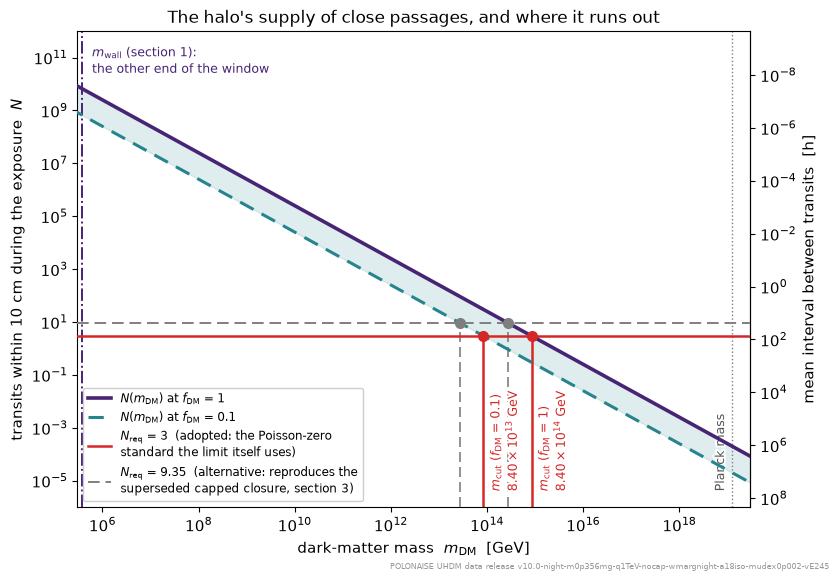

In [7]:
MS_FLUX = np.geomspace(2e5, 3e19, 400)
CUTS = [(1.0, N_REQ), (1.0, N_REQ_ALT), (0.1, N_REQ), (0.1, N_REQ_ALT)]

print(f"{'m [GeV]':>11} {'N (f=1)':>11} {'N (f=0.1)':>11} "
      f"{'mean interval':>16}")
for m in (1e8, 1e12, mass_cut(1.0, N_REQ_ALT), mass_cut(1.0, N_REQ), 1e15,
          M_PLANCK):
    gap_h = T_TOTAL / n_transits(m, 1.0) / 3600
    gap = (f"{gap_h * 3600 * 1e3:.0f} ms" if gap_h < 1 / 60 else
           f"{gap_h * 60:.1f} min" if gap_h < 1 else
           f"{gap_h:.0f} h" if gap_h < 8766 else
           f"{gap_h / 8766:.0f} yr")
    print(f"{m:>11.3e} {n_transits(m, 1.0):>11.3e} "
          f"{n_transits(m, 0.1):>11.3e} {gap:>16}")

# --- figure 1: the transit curve and the two candidate cuts -----------------
fig, ax = plt.subplots(figsize=(8.4, 5.8))
ax.set_xscale("log")
ax.set_yscale("log")
YLIM = (1e-6, 1e12)

ax.fill_between(MS_FLUX, n_transits(MS_FLUX, 0.1), n_transits(MS_FLUX, 1.0), color=C_MID,
                alpha=0.14, zorder=1)
ax.plot(MS_FLUX, n_transits(MS_FLUX, 1.0), color=C_DARK, lw=2.6, zorder=5,
        label=r"$N(m_\mathrm{DM})$ at $f_\mathrm{DM}$ = 1")
ax.plot(MS_FLUX, n_transits(MS_FLUX, 0.1), color=C_MID, lw=2.2, ls=(0, (5, 3)), zorder=5,
        label=r"$N(m_\mathrm{DM})$ at $f_\mathrm{DM}$ = 0.1")

# the two candidate requirements
ax.axhline(N_REQ, color=C_RED, lw=1.8, zorder=4,
           label=f"$N_\\mathrm{{req}}$ = {N_REQ:g}  (adopted: the Poisson-zero"
                 "\nstandard the limit itself uses)")
ax.axhline(N_REQ_ALT, color=C_GRAY, lw=1.4, ls=(0, (6, 3)), zorder=4,
           label=f"$N_\\mathrm{{req}}$ = {N_REQ_ALT:g}  (alternative: "
                 "reproduces the\nsuperseded capped closure, section 3)")

# the four cut masses
for f_dm, n_req in CUTS:
    m_c = mass_cut(f_dm, n_req)
    adopted = n_req == N_REQ
    col = C_RED if adopted else C_GRAY
    ax.plot([m_c, m_c], [YLIM[0], n_req], color=col, lw=1.8 if adopted else 1.2,
            ls="-" if adopted else (0, (6, 3)), zorder=3)
    ax.plot([m_c], [n_req], "o", ms=7, color=col, zorder=6)
for f_dm in (1.0, 0.1):
    m_c = mass_cut(f_dm, N_REQ)
    halo_text(ax.text(m_c * 1.25, 4e-6,
                      f"$m_\\mathrm{{cut}}$ ($f_\\mathrm{{DM}}$ = {f_dm:g})\n"
                      f"{fmt_pow(m_c)} GeV",
                      fontsize=9, color=C_RED, ha="left", va="bottom",
                      rotation=90), 3.0)

# the sensor's own scale, and the Planck mass
ax.axvline(M_PLANCK, color=C_GRAY, lw=1.0, ls=":", zorder=2)
halo_text(ax.text(M_PLANCK * 0.8, 4e-6, "Planck mass", fontsize=9,
                  color=C_GUIDE, ha="right", va="bottom", rotation=90), 2.8)
ax.axvline(M_WALL, color=C_DARK, lw=1.4, ls="-.", zorder=2)
halo_text(ax.text(M_WALL * 1.6, 3e11,
                  "$m_\\mathrm{wall}$ (section 1):\nthe other end of the "
                  "window", fontsize=9, color=C_DARK, ha="left",
                  va="top"), 3.0)

# the mean interval between transits, on the right
sec = ax.secondary_yaxis(
    "right", functions=(lambda n: T_TOTAL / np.maximum(n, 1e-300) / 3600,
                        lambda h: T_TOTAL / np.maximum(h, 1e-300) / 3600))
sec.set_ylabel("mean interval between transits  [h]")

ax.set_xlim(3e5, 3e19)
ax.set_ylim(*YLIM)
ax.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
ax.set_ylabel(f"transits within {B_CAP * 100:g} cm during the exposure  $N$")
ax.set_title("The halo's supply of close passages, and where it runs out")
ax.legend(loc="lower left", fontsize=8.4, framealpha=0.95)
fig.tight_layout()
save_figure(fig, "11_transit_curve")
plt.show()

## 7. The uncapped contour against the cut

Everything in this section is the mode-1 band, drawn from both released files.
The other two modes have their own bands and their own endpoints, and the mode
ordering is not fixed across builds, so the panels below say which mode they
are.

The released surfaces do not close on the right. For the massless mediator the
95% CL band is still non-empty at $1.22\times10^{19}$ GeV, the last mass on the
grid, in both files: nothing in the uncapped cross section ever stops working,
so the exclusion runs off the end of the axis. What the band does do is climb —
at fixed $\mu$ the count scales as $\alpha_n^{2}/m_\mathrm{DM}$, so the floor of
the band rises roughly as $\sqrt{m_\mathrm{DM}}$, from
$4.0\times10^{-9}$ at its deepest to $1.2\times10^{-5}$ where the cut falls.

$m_\mathrm{cut}$ is where that surface stops being a claim. Beyond it the halo
supplies fewer than $N_\mathrm{req}$ expected transits within 10 cm during the
exposure, so the excluded region there is an extrapolation of the cross section
into a regime the exposure never sampled.

The finite-range slices are a different story: they close on their own, and far
below the cut. A Yukawa of range $\lambda$ delivers no impulse to an impact
parameter much beyond $\lambda$, so as the mass rises the coupling needed
outruns the grid long before the flux argument bites — 2 mm closes at
$2.3\times10^{13}$ GeV, 200 µm at $2.1\times10^{11}$, 20 µm at
$2.6\times10^{9}$. The flux cut therefore only ever touches the massless
(Coulomb-reach) surface, which is the one the Letter's mass window is quoted
from.

massless mediator, mode 1: right end of the released band
  f_DM = 1, atm        last excluded grid mass 1.2200e+19 GeV (grid top 1.2200e+19);  m_cut = 8.4012e+14
  f_DM = 0.1, no atm   last excluded grid mass 1.2200e+19 GeV (grid top 1.2200e+19);  m_cut = 8.4012e+13

finite ranges close on their own, well below the cut:
  f_DM = 1, atm        2mm    : closes at 2.2715e+13 GeV (2.7e-02 x m_cut)
  f_DM = 1, atm        200um  : closes at 2.1229e+11 GeV (2.5e-04 x m_cut)
  f_DM = 1, atm        20um   : closes at 2.6116e+09 GeV (3.1e-06 x m_cut)
  f_DM = 0.1, no atm   2mm    : closes at 2.5195e+12 GeV (3.0e-02 x m_cut)
  f_DM = 0.1, no atm   200um  : closes at 3.0995e+10 GeV (3.7e-04 x m_cut)
  f_DM = 0.1, no atm   20um   : closes at 2.2005e+08 GeV (2.6e-06 x m_cut)

band floor at the cut (f_DM = 1): alpha_n = 1.223e-05 at m = 8.0947e+14; deepest floor 3.993e-09


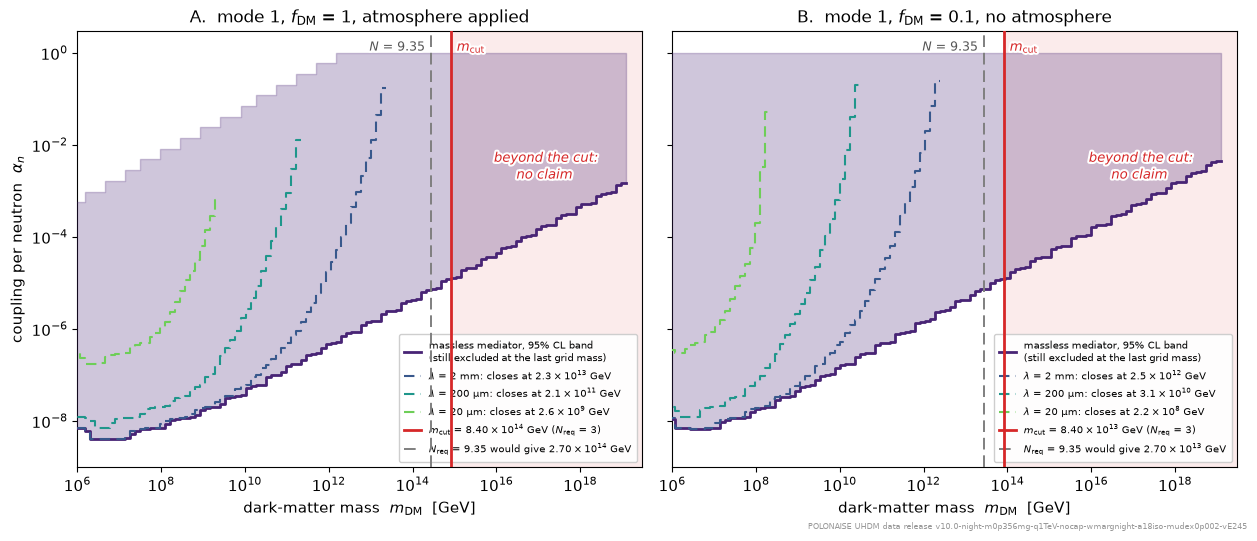

In [8]:
# LO_A/HI_A and LO_B/HI_B were built in section 2, from the same recipe
print(f"massless mediator, mode {MODE}: right end of the released band")
for tag, lo, f_dm in (("f_DM = 1, atm", LO_A, 1.0),
                      ("f_DM = 0.1, no atm", LO_B, 0.1)):
    ok = np.where(np.isfinite(lo))[0]
    print(f"  {tag:20s} last excluded grid mass {MS_GRID[ok[-1]]:.4e} GeV "
          f"(grid top {MS_GRID[-1]:.4e});  m_cut = "
          f"{mass_cut(f_dm, N_REQ):.4e}")

print("\nfinite ranges close on their own, well below the cut:")
CLOSURES = {}
for tag, r, f_dm, atmo in (("f_DM = 1, atm", rel, 1.0, True),
                           ("f_DM = 0.1, no atm", relB, 0.1, False)):
    for lam in LAMBDAS[1:]:
        lo, _ = band_of(r, lam, f_dm, atmo)
        ok = np.where(np.isfinite(lo))[0]
        m_close = float(r.axes.mass_gev[ok[-1]])
        CLOSURES[(f_dm, lam)] = m_close
        print(f"  {tag:20s} {lam:7s}: closes at {m_close:.4e} GeV "
              f"({m_close / mass_cut(f_dm, N_REQ):.1e} x m_cut)")

i_cut = int(np.argmin(np.abs(MS_GRID - mass_cut(1.0, N_REQ))))
print(f"\nband floor at the cut (f_DM = 1): alpha_n = {LO_A[i_cut]:.3e} "
      f"at m = {MS_GRID[i_cut]:.4e}; deepest floor {np.nanmin(LO_A):.3e}")

# --- figure 2: the uncapped band and the cut, for both files ----------------
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.4), sharey=True)
PANELS = [(axes[0], f"A.  mode {MODE}, $f_\\mathrm{{DM}}$ = 1, atmosphere "
           "applied", LO_A, HI_A, 1.0),
          (axes[1], f"B.  mode {MODE}, $f_\\mathrm{{DM}}$ = 0.1, no "
           "atmosphere", LO_B, HI_B, 0.1)]

for ax, title, lo, hi, f_dm in PANELS:
    ax.set_xscale("log")
    ax.set_yscale("log")
    m_c, m_c_alt = mass_cut(f_dm, N_REQ), mass_cut(f_dm, N_REQ_ALT)
    ok = np.isfinite(lo)
    ax.fill_between(MS_GRID[ok], lo[ok], hi[ok], color=C_DARK, alpha=0.26,
                    step="pre", zorder=3)
    ax.step(MS_GRID[ok], lo[ok], where="pre", color=C_DARK, lw=2.0, zorder=4,
            label="massless mediator, 95% CL band\n"
                  "(still excluded at the last grid mass)")

    # the finite ranges, which close on their own
    for lam in LAMBDAS[1:]:
        lo_l, _ = band_of(rel if f_dm == 1.0 else relB, lam, f_dm,
                          f_dm == 1.0)
        okl = np.isfinite(lo_l)
        ax.step(MS_GRID[okl], lo_l[okl], where="pre", color=LAM_COL[lam],
                lw=1.5, ls=(0, (5, 3)), zorder=5,
                label=f"{LAM_LABEL[lam]}: closes at "
                      f"{fmt_pow(MS_GRID[okl][-1], 1)} GeV")

    # beyond the cut: no claim
    ax.axvspan(m_c, 1e20, color=C_RED, alpha=0.09, zorder=1)
    ax.axvline(m_c, color=C_RED, lw=2.0, zorder=6,
               label=f"$m_\\mathrm{{cut}}$ = {fmt_pow(m_c)} GeV "
                     f"($N_\\mathrm{{req}}$ = {N_REQ:g})")
    ax.axvline(m_c_alt, color=C_GRAY, lw=1.4, ls=(0, (6, 3)), zorder=6,
               label=f"$N_\\mathrm{{req}}$ = {N_REQ_ALT:g} would give "
                     f"{fmt_pow(m_c_alt)} GeV")
    halo_text(ax.text(m_c * 1.35, 1.85, "$m_\\mathrm{cut}$", fontsize=9.5,
                      color=C_RED, ha="left", va="top"), 3.0)
    halo_text(ax.text(m_c_alt * 0.75, 1.85, f"$N$ = {N_REQ_ALT:g}",
                      fontsize=9, color=C_GUIDE, ha="right", va="top"), 3.0)
    halo_text(ax.text(1.4e17, 8e-3, "beyond the cut:\nno claim", fontsize=9.5,
                      color=C_RED, ha="center", va="top", style="italic"), 3.0)
    ax.set_xlim(1e6, 3e19)
    ax.set_ylim(1e-9, 3.0)
    ax.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=7.4, framealpha=0.95,
              handlelength=1.6, borderpad=0.5)

axes[0].set_ylabel(r"coupling per neutron  $\alpha_n$")
fig.tight_layout()
save_figure(fig, "11_contour_vs_cut")
plt.show()

## 8. The superseded capped closure, and what $N_\mathrm{req}$ buys

The earlier analysis reached the same physical conclusion by a different route.
It clipped the outer edge of the impact-parameter integral at
$b \le b_\mathrm{cap} = 10$ cm inside the cross section itself, so the counted
rate came only from flybys within the aperture. That version *did* close on the
right, at $2.70\times10^{14}$ GeV for $f_\mathrm{DM} = 1$ — and it closed for
precisely the reason the flux argument names, since a capped $b$-integral has a
finite geometric cross section and the transit supply is what it runs out of.
That cube is an internal file rather than part of the release, so its band is
not redrawn here; the two closure masses it contributes are frozen constants in
the setup cell — historical anchors, not results of this release — and
everything else in this section is arithmetic on top of them.

The two routes differ in bookkeeping, not in mechanism, and the flux cut is the
more honest of the two. A cap inside the cross section changes the shape of
$d\sigma/dq$ everywhere, not only at high mass — it removes the soft flybys,
grows a projection horn at $q_* = 2\alpha/(v\,b_\mathrm{cap})$ (drawn in
`png/07_impact_parameter_cap.png`) and
so alters the limit at masses where the transit supply is in the millions and
nothing needed to be cut. Applying the same physics afterwards, as a line in
mass, leaves every stored surface uncapped and puts the choice where a reader
can see it.

Where they differ is *how many* transits the earlier closure implicitly
demanded. Solving $N(m) = N_\mathrm{req}$ at the capped closure mass, with this
release's lab-frame $\langle v \rangle$, gives $N_\mathrm{req} = 9.35$: the
capped analysis stopped claiming when the halo still supplied about nine expected
passages, three times as strict as the Poisson-zero standard. In mass the
difference is a factor 3.12, or 0.49 of a decade — small on the scale of the
nine-decade window, and the reason both lines are worth drawing rather than
arguing about. The calibration is only good to about a grid step: the same
exercise on the $f_\mathrm{DM} = 0.1$ capped closure lands one mass grid point
lower and reads $N_\mathrm{req} = 11.1$, and the grid spacing is a factor 1.32.
Both numbers are flux statements and so move with the halo frame: in the
Galactic rest frame of the pre-v10 releases the same anchors read 6.8 and 8.1,
smaller by the ratio of the two mean speeds.

$m_\mathrm{cut} \propto 1/N_\mathrm{req}$, so the whole family is one line on
log axes; panel B draws it, with the two candidate values and the capped
closure marked.

superseded capped analysis: v5.0-night-m0p356mg-bcap10cm   b_constrained_max = 0.1 m   q_thresh = 100 GeV
  (internal cube, not part of the release; its two mode-1 massless closure masses are frozen in the setup cell)
  f_DM =    1: capped closure at 2.6959e+14 GeV  ->  implies N_req = 9.35
  f_DM =  0.1: capped closure at 2.2715e+13 GeV  ->  implies N_req = 11.10

  N_req    m_cut (f=1)  m_cut (f=0.1)  note
      1     2.5204e+15     2.5204e+14  
      3     8.4012e+14     8.4012e+13  adopted (Poisson-zero standard)
   9.35     2.6956e+14     2.6956e+13  reproduces the superseded capped closure
     10     2.5204e+14     2.5204e+13  
    100     2.5204e+13     2.5204e+12  

ratio m_cut(N=3)/m_cut(N=9.35) = 3.12 = 0.49 decades


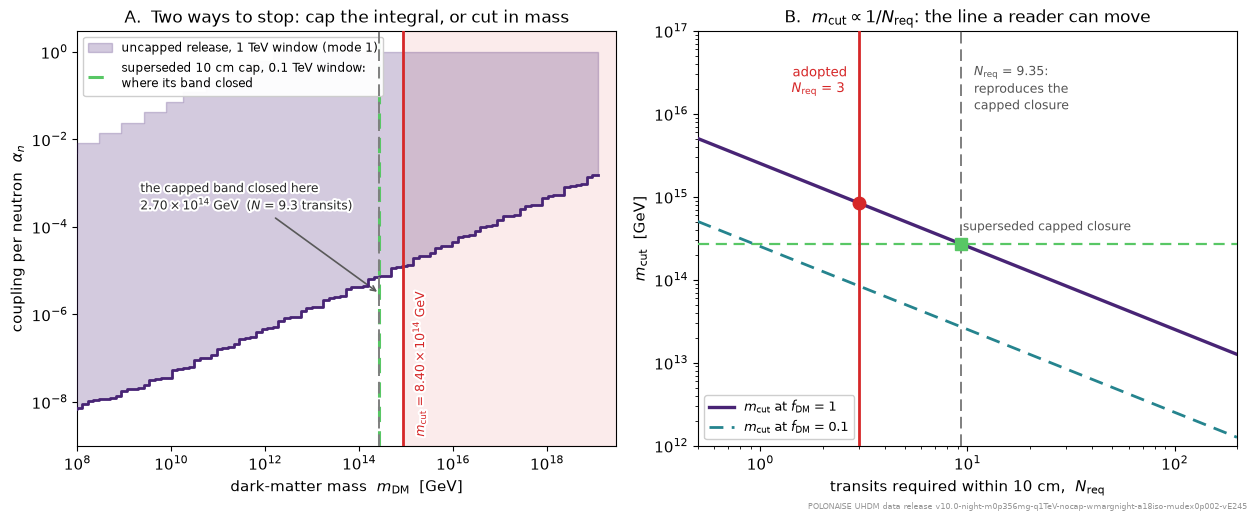

In [9]:
print(f"superseded capped analysis: {CAPPED_TAG}   b_constrained_max = "
      f"{B_CAP:g} m   q_thresh = {CAPPED_WINDOW_GEV:.0f} GeV")
print("  (internal cube, not part of the release; its two mode-1 massless "
      "closure masses are frozen in the setup cell)")
for f_dm in (1.0, 0.1):
    n_implied = n_transits(M_CLOSE_CAPPED[f_dm], f_dm)
    print(f"  f_DM = {f_dm:>4g}: capped closure at "
          f"{M_CLOSE_CAPPED[f_dm]:.4e} GeV  ->  implies N_req = "
          f"{n_implied:.2f}")

print(f"\n{'N_req':>7} {'m_cut (f=1)':>14} {'m_cut (f=0.1)':>14}  note")
for n_req in (1.0, N_REQ, N_REQ_ALT, 10.0, 100.0):
    note = ""
    if n_req == N_REQ:
        note = "adopted (Poisson-zero standard)"
    elif n_req == N_REQ_ALT:
        note = "reproduces the superseded capped closure"
    print(f"{n_req:>7g} {mass_cut(1.0, n_req):>14.4e} "
          f"{mass_cut(0.1, n_req):>14.4e}  {note}")
print(f"\nratio m_cut(N={N_REQ:g})/m_cut(N={N_REQ_ALT:g}) = "
      f"{N_REQ_ALT / N_REQ:.2f} "
      f"= {np.log10(N_REQ_ALT / N_REQ):.2f} decades")

# --- figure 3: the capped closure and the N_req family ----------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.6, 5.2))

# --- A: the two schemes at the high-mass end (f_DM = 1) ---
axA.set_xscale("log")
axA.set_yscale("log")
ok = np.isfinite(LO_A)
axA.fill_between(MS_GRID[ok], LO_A[ok], HI_A[ok], color=C_DARK, alpha=0.24,
                 step="pre", zorder=3,
                 label=f"uncapped release, 1 TeV window (mode {MODE})")
axA.step(MS_GRID[ok], LO_A[ok], where="pre", color=C_DARK, lw=2.0, zorder=4)
# The capped band itself is not drawn: that cube is internal and not shipped.
# Only its closure mass is carried, as a frozen constant.
m5 = M_CLOSE_CAPPED[1.0]
axA.axvline(m5, color=C_LIGHT, lw=2.2, ls=(0, (5, 3)), zorder=5,
            label="superseded 10 cm cap, 0.1 TeV window:\n"
                  "where its band closed")
an = axA.annotate(f"the capped band closed here\n{fmt_pow(m5)} GeV  "
                  f"($N$ = {n_transits(m5, 1.0):.1f} transits)",
                  xy=(m5, 3.0e-6), xytext=(2.2e9, 2.0e-4), fontsize=8.8,
                  color="0.15", ha="left", va="bottom",
                  arrowprops=dict(arrowstyle="->", color="0.35", lw=1.2))
halo_text(an, 3.0)
m_c = mass_cut(1.0, N_REQ)
axA.axvspan(m_c, 1e20, color=C_RED, alpha=0.09, zorder=1)
axA.axvline(m_c, color=C_RED, lw=2.0, zorder=6)
halo_text(axA.text(m_c * 1.6, 1.6e-9,
                   f"$m_\\mathrm{{cut}}$ = {fmt_pow(m_c)} GeV", fontsize=9,
                   color=C_RED, ha="left", va="bottom", rotation=90), 3.0)
axA.axvline(mass_cut(1.0, N_REQ_ALT), color=C_GRAY, lw=1.4, ls=(0, (6, 3)),
            zorder=6)
axA.set_xlim(1e8, 3e19)
axA.set_ylim(1e-9, 3.0)
axA.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
axA.set_ylabel(r"coupling per neutron  $\alpha_n$")
axA.set_title("A.  Two ways to stop: cap the integral, or cut in mass")
axA.legend(loc="upper left", fontsize=8.6, framealpha=0.95)

# --- B: the whole N_req family ---
axB.set_xscale("log")
axB.set_yscale("log")
NN = np.geomspace(0.5, 200, 300)
axB.plot(NN, mass_cut(1.0, NN), color=C_DARK, lw=2.4, zorder=4,
         label=r"$m_\mathrm{cut}$ at $f_\mathrm{DM}$ = 1")
axB.plot(NN, mass_cut(0.1, NN), color=C_MID, lw=2.0, ls=(0, (5, 3)), zorder=4,
         label=r"$m_\mathrm{cut}$ at $f_\mathrm{DM}$ = 0.1")
axB.axvline(N_REQ, color=C_RED, lw=2.0, zorder=5)
axB.plot([N_REQ], [mass_cut(1.0, N_REQ)], "o", ms=9, color=C_RED, zorder=7)
halo_text(axB.text(N_REQ * 0.86, 4e16,
                   f"adopted\n$N_\\mathrm{{req}}$ = {N_REQ:g}", fontsize=9.5,
                   color=C_RED, ha="right", va="top"), 3.0)
axB.axvline(N_REQ_ALT, color=C_GRAY, lw=1.4, ls=(0, (6, 3)), zorder=5)
halo_text(axB.text(N_REQ_ALT * 1.15, 4e16,
                   f"$N_\\mathrm{{req}}$ = {N_REQ_ALT:g}:\nreproduces the\n"
                   "capped closure", fontsize=9, color=C_GUIDE, ha="left",
                   va="top"), 3.0)
axB.axhline(M_CLOSE_CAPPED[1.0], color=C_LIGHT, lw=1.6, ls=(0, (5, 3)),
            zorder=3)
axB.plot([N_REQ_ALT], [M_CLOSE_CAPPED[1.0]], "s", ms=8, color=C_LIGHT,
         zorder=7)
halo_text(axB.text(60, M_CLOSE_CAPPED[1.0] * 1.35,
                   "superseded capped closure", fontsize=8.8,
                   color=C_GUIDE, ha="right", va="bottom"), 3.0)
axB.set_xlim(NN[0], NN[-1])
axB.set_ylim(1e12, 1e17)
axB.set_xlabel(r"transits required within 10 cm,  $N_\mathrm{req}$")
axB.set_ylabel(r"$m_\mathrm{cut}$  [GeV]")
axB.set_title(r"B.  $m_\mathrm{cut} \propto 1/N_\mathrm{req}$: the line a "
              "reader can move")
axB.legend(loc="lower left", fontsize=9, framealpha=0.95)

fig.tight_layout()
save_figure(fig, "11_capped_vs_flux_cut")
plt.show()

## 9. The shell of validity: why the aperture is 10 cm

Nothing so far explains the choice $b_\mathrm{cap} = 10$ cm. It is not a
property of the halo and not a property of the cross section; it is the scale of
the apparatus, and it is where the *measurement* changes character.

A flyby at impact parameter $b$ pulls on everything within roughly $b$ of it.
While $b$ is small compared with the hardware, that means the levitated magnet
and nothing else: the magnet is accelerated relative to its trap, and the
differential read-out records an impulse. Once $b$ grows past the scale of the
apparatus the same flyby pulls on the magnet *and* on the trap that defines its
zero — the two see nearly the same acceleration, the response becomes
common-mode, and a differential read-out suppresses it. It does not become
zero — the residual goes as the gradient of the field across the instrument
rather than the field itself — but the analysis has no calibration for that
regime and does not model it. Ten centimetres is the honest outer edge of the
shell the detector was characterised in, so it is the aperture the supply
argument is asked about.

That is a separate statement from the flux cut, and it is worth seeing where the
two meet on the surface. The threshold reach — the largest impact parameter that
still delivers $q_\mathrm{min}$ — is stored in the release as the flux-averaged
$b_\mathrm{max}$ on the halo grid, and above the wall it depends only on the
coupling. It equals the sensor radius $R_\mathrm{eff}$ = 260 µm at
$\alpha_n = 7.4\times10^{-9}$ — within a factor of two of the deepest point of
the exclusion floor, $\alpha_n = 4.0\times10^{-9}$, though the two are separate
quantities and only the reach is fixed by the halo grid — and it reaches 10 cm
at $\alpha_n = 2.4\times10^{-6}$. Between those two it is simply linear,
$b_\mathrm{max} = 2\alpha/(q_\mathrm{min}v)$ flux-averaged over $v$; below
$R_\mathrm{eff}$ it falls away faster, because only the slowest flybys still
clear the sensor radius and the halo has few of those.

Because the floor of the band climbs with mass, the couplings that carry the
exclusion cross that value around $m_\mathrm{DM} = 3.0\times10^{13}$ GeV.
Above that mass every excluded coupling has a threshold reach larger than the
apparatus, so the counted rate there is dominated by flybys the differential
read-out would suppress. This notebook does not turn that into a second cut —
the released window is bounded by $m_\mathrm{cut}$ and nothing else — but it is
the reason the aperture in the flux argument is a hardware scale rather than a
free parameter, and it is a caveat to carry when reading the top decade and a
half below $m_\mathrm{cut}$.

threshold reach = R_eff = 260 um at alpha_n = 7.421e-09
threshold reach = b_cap = 10 cm at alpha_n = 2.422e-06
the band floor's reach first exceeds 10 cm at m = 2.990e+13 GeV (alpha_n = 2.42e-06)
  at m = 2.696e+14: floor alpha_n = 7.12e-06, reach = 0.294 m = 2.9 x b_cap
  at m = 8.095e+14: floor alpha_n = 1.22e-05, reach = 0.505 m = 5.0 x b_cap


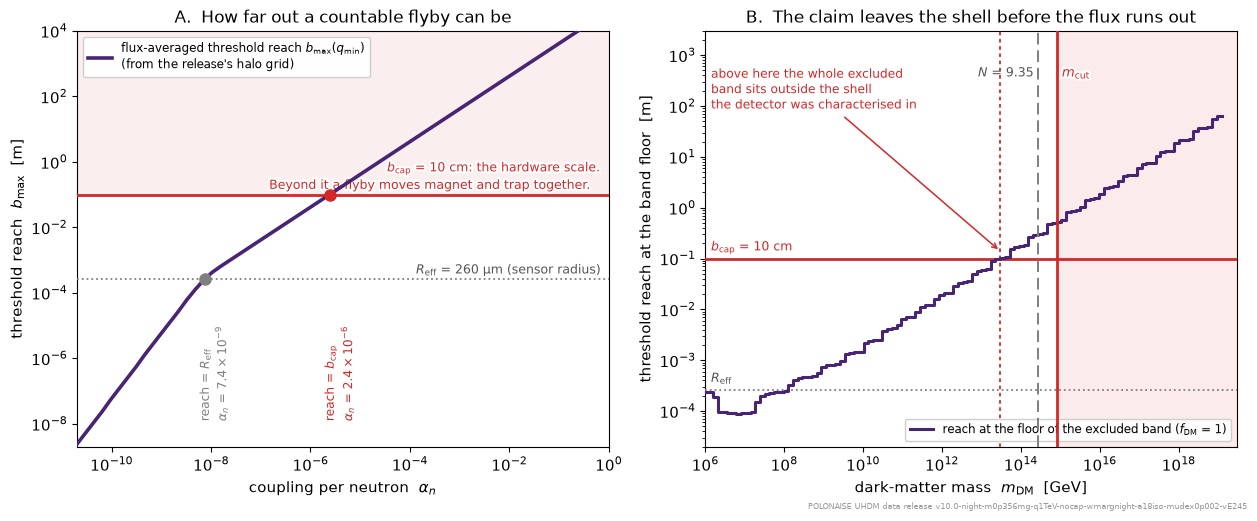

In [10]:
# the flux-averaged threshold reach, from the cube's own halo grid
BMAX = rel.mass_plane("bmax", mode=None, lam="massless", group="halo")
A_HALO = rel.axes_halo.alpha_n
M_HALO = rel.axes_halo.mass_gev
i_heavy = M_HALO.size - 10            # any mass well above the wall: b is
reach = BMAX[:, i_heavy]              # mass-independent there
ok = reach > 0
assert np.allclose(reach[:, None], BMAX[:, M_HALO > 1e12],
                   rtol=1e-6), "threshold reach is not mass-independent"


def alpha_at_reach(b_m):
    """Coupling whose flux-averaged threshold reach is b_m [m]."""
    return float(np.exp(np.interp(np.log(b_m), np.log(reach[ok]),
                                  np.log(A_HALO[ok]))))


def reach_at_alpha(a_n):
    """Flux-averaged threshold reach [m] at this coupling."""
    return np.exp(np.interp(np.log(a_n), np.log(A_HALO[ok]),
                            np.log(reach[ok])))


A_SHELL = alpha_at_reach(B_CAP)
A_REFF = alpha_at_reach(R_EFF)
print(f"threshold reach = R_eff = {R_EFF * 1e6:.0f} um at alpha_n = "
      f"{A_REFF:.3e}")
print(f"threshold reach = b_cap = {B_CAP * 100:g} cm at alpha_n = "
      f"{A_SHELL:.3e}")

reach_floor = reach_at_alpha(LO_A)
sel = np.isfinite(LO_A)
i_shell = int(np.where(sel & (reach_floor > B_CAP))[0][0])
print(f"the band floor's reach first exceeds {B_CAP * 100:g} cm at "
      f"m = {MS_GRID[i_shell]:.3e} GeV (alpha_n = {LO_A[i_shell]:.2e})")
for m_t in (mass_cut(1.0, N_REQ_ALT), mass_cut(1.0, N_REQ)):
    i_t = int(np.argmin(np.abs(MS_GRID - m_t)))
    print(f"  at m = {MS_GRID[i_t]:.3e}: floor alpha_n = {LO_A[i_t]:.2e}, "
          f"reach = {reach_floor[i_t]:.3f} m = "
          f"{reach_floor[i_t] / B_CAP:.1f} x b_cap")

# --- figure 4: the reach against the hardware scale -------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.6, 5.2))

# --- A: reach vs coupling ---
axA.set_xscale("log")
axA.set_yscale("log")
axA.fill_between(A_HALO[ok], B_CAP, 1e4, color=C_RED, alpha=0.08, zorder=1)
axA.plot(A_HALO[ok], reach[ok], color=C_DARK, lw=2.6, zorder=5,
         label="flux-averaged threshold reach $b_\\mathrm{max}(q_\\mathrm{min})$"
               "\n(from the release's halo grid)")
axA.axhline(B_CAP, color=C_RED, lw=2.0, zorder=4)
halo_text(axA.text(0.7, B_CAP * 1.5,
                   f"$b_\\mathrm{{cap}}$ = {B_CAP * 100:g} cm: the hardware "
                   "scale.\nBeyond it a flyby moves magnet and trap together.",
                   fontsize=9, color=C_RED, ha="right"), 3.0)
axA.axhline(R_EFF, color=C_GRAY, lw=1.3, ls=":", zorder=4)
halo_text(axA.text(0.7, R_EFF * 1.5,
                   f"$R_\\mathrm{{eff}}$ = {R_EFF * 1e6:.0f} µm (sensor radius)",
                   fontsize=9, color=C_GUIDE, ha="right"), 2.8)
for a_v, lab, col in ((A_REFF, "reach = $R_\\mathrm{eff}$", C_GRAY),
                      (A_SHELL, "reach = $b_\\mathrm{cap}$", C_RED)):
    axA.plot([a_v], [reach_at_alpha(a_v)], "o", ms=8, color=col, zorder=6)
    halo_text(axA.text(a_v * 0.72, 1.2e-8, f"{lab}\n$\\alpha_n$ = "
                       f"{fmt_pow(a_v, 1)}", fontsize=8.8, color=col,
                       ha="left", va="bottom", rotation=90), 3.0)
axA.set_xlim(2e-11, 1.0)
axA.set_ylim(2e-9, 1e4)
axA.set_xlabel(r"coupling per neutron  $\alpha_n$")
axA.set_ylabel(r"threshold reach  $b_\mathrm{max}$  [m]")
axA.set_title("A.  How far out a countable flyby can be")
axA.legend(loc="upper left", fontsize=8.6, framealpha=0.95)

# --- B: the reach the exclusion floor actually uses, vs mass ---
axB.set_xscale("log")
axB.set_yscale("log")
m_c = mass_cut(1.0, N_REQ)
axB.axvspan(m_c, 1e20, color=C_RED, alpha=0.09, zorder=1)
axB.step(MS_GRID[sel], reach_floor[sel], where="pre", color=C_DARK, lw=2.2,
         zorder=5, label="reach at the floor of the excluded band "
                         "($f_\\mathrm{DM}$ = 1)")
axB.axhline(B_CAP, color=C_RED, lw=2.0, zorder=4)
halo_text(axB.text(1.4e6, B_CAP * 1.45,
                   f"$b_\\mathrm{{cap}}$ = {B_CAP * 100:g} cm", fontsize=9,
                   color=C_RED), 3.0)
axB.axhline(R_EFF, color=C_GRAY, lw=1.3, ls=":", zorder=4)
halo_text(axB.text(1.4e6, R_EFF * 1.45, "$R_\\mathrm{eff}$", fontsize=9,
                   color=C_GUIDE), 2.8)
axB.axvline(MS_GRID[i_shell], color=C_RED, lw=1.3, ls=(0, (2, 2)), zorder=4)
an = axB.annotate("above here the whole excluded\nband sits outside the shell\n"
                  "the detector was characterised in",
                  xy=(MS_GRID[i_shell], 0.14), xytext=(1.4e6, 6e2),
                  fontsize=8.8, color=C_RED, ha="left", va="top",
                  arrowprops=dict(arrowstyle="->", color=C_RED, lw=1.1))
halo_text(an, 3.0)
axB.axvline(m_c, color=C_RED, lw=2.0, zorder=6)
halo_text(axB.text(m_c * 1.3, 6e2, "$m_\\mathrm{cut}$", fontsize=9.5,
                   color=C_RED, ha="left", va="top"), 3.0)
axB.axvline(mass_cut(1.0, N_REQ_ALT), color=C_GRAY, lw=1.4, ls=(0, (6, 3)),
            zorder=6)
halo_text(axB.text(mass_cut(1.0, N_REQ_ALT) * 0.8, 6e2, f"$N$ = {N_REQ_ALT:g}",
                   fontsize=9, color=C_GUIDE, ha="right", va="top"), 3.0)
axB.set_xlim(1e6, 3e19)
axB.set_ylim(2e-5, 3e3)
axB.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
axB.set_ylabel(r"threshold reach at the band floor  [m]")
axB.set_title("B.  The claim leaves the shell before the flux runs out")
axB.legend(loc="lower right", fontsize=8.4, framealpha=0.95)

fig.tight_layout()
save_figure(fig, "11_shell_of_validity")
plt.show()

## 10. Numerical self-consistency checks

Everything asserted above, re-checked in one place. The first six are the left
edge and the pipeline; the last six are the flux cut.

1. The cube is uncapped, its threshold is 1 TeV and its projection kernel is
   the one every recomputation here is built with — all from the file
   attributes, and the two released files agree on the kernel.
2. `mu_of` reproduces the release cube's stored `mu` cells (the
   atmosphere-off file, whose pass uses the bare halo this notebook computes).
3. The wall equals `q_thresh_gev / v_max`, with `v_max = v_esc + v_E` at this
   file's recorded halo frame, and it is bracketed by two adjacent release grid
   masses.
4. No mediator slice's first excluded grid mass sits below the first grid mass
   above the wall, and on all but the shortest bare-halo range it is exactly
   that mass.
5. Below the wall the detected spectrum has no support: the trimmed spectrum is
   `None` and $\mu$ is exactly zero, at couplings spanning eleven decades.
6. The tail fraction reaches one half at $m_\mathrm{typ}$, as the definition of
   $\langle v \rangle$ requires.
7. $m_\mathrm{cut}$ recomputed here reproduces the value stored in each file's
   attributes, bit for bit at float precision, and $\langle v \rangle$ matches
   the number quoted in the file's own derivation string.
8. $N(m_\mathrm{cut}) = N_\mathrm{req}$ exactly, and $m_\mathrm{cut}$ scales
   linearly with $f_\mathrm{DM}$.
9. The cut is *not* baked into the stored surfaces: the attribute says so, and
   the massless band is still excluded at the last grid mass, past the cut.
10. $N_\mathrm{req} = 9.35$ reproduces the frozen capped closure mass to better
    than a percent.
11. The finite-range slices close on their own below $m_\mathrm{cut}$, so the cut
    only ever touches the massless surface.
12. The threshold reach stored on the halo grid is mass-independent above the
    wall and linear in the coupling, as the Coulomb form
    $b_\mathrm{max} = 2\alpha/(q_\mathrm{min} v)$ requires.

In [11]:
# 1 -- what the file says about the scheme
print(f"1. q_thresh_gev = {rel.attrs['q_thresh_gev']:.0f} GeV, "
      f"b_constrained_max = {rel.b_constrained_max}, "
      f"t_exposure_s = {rel.attrs['t_exposure_s']:,.0f}, "
      f"projection_kernel = {rel.projection_kernel}")
assert float(rel.attrs["q_thresh_gev"]) == Q_MIN
assert rel.b_constrained_max is None
# check 2 recomputes with file A's handle and compares against file B's cells,
# so the two files must name the same projection convention
assert rel.projection_kernel == relB.projection_kernel, \
    "the two released files were built with different projection kernels"
assert XS["projection_kernel"] == rel.projection_kernel

# 2 -- replication against the cube's own mu cells (bare-halo pass, file B)
MU_CUBE = relB.mass_plane("mu", mode=MODE, lam="massless", f_dm=0.1,
                          atmosphere=False)
# a stride over both axes rather than pinned indices, so the check samples the
# same spread of cells whatever the release's grid resolution is; cells with no
# expected counts (below the wall, or where the spectrum has no support) carry
# no ratio to compare and are skipped
diffs = []
for im in range(0, MS_GRID.size, 7):
    for ia in range(0, AS_GRID.size, 3):
        cube = float(MU_CUBE[ia, im])
        if np.isfinite(cube) and cube > 0:
            diffs.append(abs(mu_of(MS_GRID[im], AS_GRID[ia], f_dm=0.1) - cube)
                         / cube)
print(f"2. replication: {len(diffs)} cells, max rel. diff = {max(diffs):.2e}")
assert len(diffs) >= 20 and max(diffs) < 1e-6

# 3 -- the wall, and the two grid masses that bracket it
i_below = int(np.where(MS_GRID < M_WALL)[0][-1])
print(f"3. wall {M_WALL:.6e} GeV bracketed by {MS_GRID[i_below]:.4e} and "
      f"{MS_GRID[i_below + 1]:.4e}")
assert np.isclose(M_WALL, float(rel.attrs["q_thresh_gev"]) / V_MAX)
assert MS_GRID[i_below] < M_WALL < MS_GRID[i_below + 1]

# 4 -- every measured edge is that same grid mass
print("4. first excluded grid mass per slice:")
for _, plain, r, f_dm, atmo in HYPOTHESES:
    for lam in LAMBDAS:
        lo, _ = band_of(r, lam, f_dm, atmo)
        i0 = int(np.where(np.isfinite(lo))[0][0])
        flag = "" if i0 == i_below + 1 else "  (one grid step later)"
        print(f"   {plain:20s} {lam:9s}: index {i0}, "
              f"m = {r.axes.mass_gev[i0]:.4e}{flag}")
        assert i0 >= i_below + 1

# 5 -- no support below the wall
print("5. spectra below the wall:")
for m in (0.7 * M_WALL, 0.99 * M_WALL):
    for a in (1e-10, 1e-6, 1e-2):
        dr = rate.differential_rate_trapz(QS, a, m, halo.standard_halo_model,
                                          XS, eff=None) * eps1(QS)
        spec = limits.spectrum_from_rate(QS, dr, T_TOTAL)
        assert spec is None or spec[0] == 0.0
    print(f"   m = {m:.4e} ({m / M_WALL:.2f} x m_wall): "
          f"spectrum_from_rate returns no support at any coupling")

# 6 -- the tail fraction turns on from exactly zero at the wall
print(f"6. Phi(m_wall) = {tail_fraction(M_WALL):.1e}, "
      f"Phi(1.0001 m_wall) = {tail_fraction(M_WALL * 1.0001):.2e}, "
      f"Phi(m_typ) = {tail_fraction(M_TYP):.3f}, "
      f"Phi(10 m_wall) = {tail_fraction(10 * M_WALL):.3f}")
assert tail_fraction(M_WALL) < 1e-12
print("   (checks 7-12, the flux cut, follow)")

1. q_thresh_gev = 1000 GeV, b_constrained_max = None, t_exposure_s = 790,778, projection_kernel = isotropic-folded


2. replication: 234 cells, max rel. diff = 5.38e-08
3. wall 3.799651e+05 GeV bracketed by 3.0026e+05 and 3.9526e+05
4. first excluded grid mass per slice:
   f_DM = 1, atm        massless : index 6, m = 5.2030e+05  (one grid step later)
   f_DM = 1, atm        2mm      : index 6, m = 5.2030e+05  (one grid step later)
   f_DM = 1, atm        200um    : index 6, m = 5.2030e+05  (one grid step later)
   f_DM = 1, atm        20um     : index 6, m = 5.2030e+05  (one grid step later)
   f_DM = 0.1, no atm   massless : index 6, m = 5.2030e+05  (one grid step later)
   f_DM = 0.1, no atm   2mm      : index 6, m = 5.2030e+05  (one grid step later)
   f_DM = 0.1, no atm   200um    : index 6, m = 5.2030e+05  (one grid step later)
   f_DM = 0.1, no atm   20um     : index 7, m = 6.8491e+05  (one grid step later)
5. spectra below the wall:
   m = 2.6598e+05 (0.70 x m_wall): spectrum_from_rate returns no support at any coupling
   m = 3.7617e+05 (0.99 x m_wall): spectrum_from_rate returns no support 

In [12]:
# 7 -- m_cut and <v> against the file attributes
for r, f_dm in ((rel, 1.0), (relB, 0.1)):
    key = f"m_cut_10cm_f{f_dm:g}_gev"
    stored = float(r.attrs[key])
    mine = mass_cut(f_dm, float(r.attrs["m_cut_n_transits_required"]),
                    float(r.attrs["m_cut_b_cap_m"]))
    print(f"7. f_DM = {f_dm:>4g}: stored {stored:.6e}  recomputed {mine:.6e}  "
          f"rel. diff {abs(mine / stored - 1):.1e}")
    assert abs(mine / stored - 1) < 1e-9
deriv = str(rel.attrs["m_cut_10cm_f1_gev_derivation"])
assert f"<v> = {V_MEAN_MS:.6g} m/s" in deriv, deriv
print(f"   <v> = {V_MEAN_MS:.6g} m/s matches the file's derivation string")

# 8 -- the definition closes on itself, and scales with f_DM
for f_dm in (1.0, 0.1):
    for n_req in (N_REQ, N_REQ_ALT):
        assert abs(n_transits(mass_cut(f_dm, n_req), f_dm) / n_req - 1) < 1e-12
print(f"8. N(m_cut) = N_req exactly for both requirements and both fractions; "
      f"m_cut(1.0)/m_cut(0.1) = "
      f"{mass_cut(1.0, N_REQ) / mass_cut(0.1, N_REQ):.1f}")
assert abs(mass_cut(1.0, N_REQ) / mass_cut(0.1, N_REQ) - 10.0) < 1e-9

# 9 -- uncapped surfaces, cut not applied
last_A = MS_GRID[np.where(np.isfinite(LO_A))[0][-1]]
print(f"9. m_cut_applied_to_stored_surfaces = "
      f"{bool(rel.attrs['m_cut_applied_to_stored_surfaces'])}; "
      f"last excluded grid mass {last_A:.3e} GeV is "
      f"{last_A / mass_cut(1.0, N_REQ):.0f}x past the cut")
assert not bool(rel.attrs["m_cut_applied_to_stored_surfaces"])
assert last_A > mass_cut(1.0, N_REQ)

# 10 -- the frozen capped closure calibrates N_req = 6.8
n_implied = n_transits(M_CLOSE_CAPPED[1.0], 1.0)
print(f"10. capped closure {M_CLOSE_CAPPED[1.0]:.4e} GeV implies "
      f"N_req = {n_implied:.3f} (quoted {N_REQ_ALT:g}, "
      f"{abs(n_implied / N_REQ_ALT - 1) * 100:.2f}% apart)")
assert abs(n_implied / N_REQ_ALT - 1) < 0.01

# 11 -- finite ranges close first
for (f_dm, lam), m_close in CLOSURES.items():
    assert m_close < mass_cut(f_dm, N_REQ)
print(f"11. all {len(CLOSURES)} finite-range slices close below their m_cut; "
      f"the largest is {max(CLOSURES.values()):.3e} GeV")

# 12 -- the reach is mass-blind, and Coulomb-linear once it clears R_eff
lin = reach > 10 * R_EFF
ratios = reach[lin] / A_HALO[lin]
print(f"12. b_max is identical across all {int((M_HALO > 1e12).sum())} masses "
      f"above 1e12 GeV; b_max/alpha_n over the {int(lin.sum())} couplings "
      f"with reach > 10 R_eff: spread {ratios.max() / ratios.min() - 1:.1e}")
assert ratios.max() / ratios.min() - 1 < 1e-4
print("\nall checks passed")

7. f_DM =    1: stored 8.401233e+14  recomputed 8.401233e+14  rel. diff 0.0e+00
7. f_DM =  0.1: stored 8.401233e+13  recomputed 8.401233e+13  rel. diff 2.2e-16
   <v> = 338173 m/s matches the file's derivation string
8. N(m_cut) = N_req exactly for both requirements and both fractions; m_cut(1.0)/m_cut(0.1) = 10.0
9. m_cut_applied_to_stored_surfaces = False; last excluded grid mass 1.220e+19 GeV is 14522x past the cut
10. capped closure 2.6959e+14 GeV implies N_req = 9.349 (quoted 9.35, 0.01% apart)
11. all 6 finite-range slices close below their m_cut; the largest is 2.272e+13 GeV
12. b_max is identical across all 32 masses above 1e12 GeV; b_max/alpha_n over the 43 couplings with reach > 10 R_eff: spread 8.8e-08

all checks passed


## Takeaway

**The left edge is arithmetic, not analysis:**

$$m_\mathrm{wall} \;=\; \frac{q_\mathrm{min}}{v_\mathrm{esc} + v_E}
\;=\; \frac{1\ \mathrm{TeV}}{789\ \mathrm{km/s}}
\;=\; 3.80\times10^{5}\ \mathrm{GeV}.$$

Below it the halo cannot put a single kick inside the analysis window, so the
expected count is exactly zero and no coupling, mediator range, exposure or
statistical method changes the answer. Above it the contour turns on over about
a decade of mass, governed by the fraction of the halo fast enough to matter:
zero at the wall, 4% at the first excluded grid mass, about a half at
$m_\mathrm{typ} = q_\mathrm{min}/\langle v \rangle = 2.3\,m_\mathrm{wall}$. That
onset costs a factor of five in the coupling at the floor of the band,
and nothing else.

The measured edge lands where the grid lets it: $5.20\times10^{5}$ GeV, the
first mass on the release axis above the wall, for every mediator slice of the
$f_\mathrm{DM} = 1$ file and all but the shortest range of its companion. Quote the wall when quoting physics and the grid mass when
quoting the file — or the refined boundary of
[`01_the_limit.ipynb`](01_the_limit.ipynb), which traces the island's tip to
$4.02\times10^{5}$ GeV, between the two grid columns that bracket the wall.

What is gone is the old ambiguity. With the window at 0.1 TeV the wall sat a
decade lower than the contour ever reached, and the edge was set by how much
efficiency penalty a rising coupling could buy back on the turn-on's cliff — a
soft boundary that moved with the grid, the endpoint convention and the
efficiency calibration. Moving the threshold to 1 TeV lifts the window edge 19
decades up that turn-on, to $\varepsilon = 0.17$ — still short of the 50% point
at 1209 GeV — and puts the wall above the old soft edge. The left edge now
depends on three numbers, all of them stated: the analysis threshold, the escape
speed, and the frame the halo is quoted in.

**The right edge is a supply statement, and it is arithmetic in the same way:**

$$m_\mathrm{cut} \;=\; \frac{f_\mathrm{DM}\,\rho_0\,\langle v \rangle\,
T_\mathrm{obs}\,\pi\,b_\mathrm{cap}^{2}}{N_\mathrm{req}}
\;=\; 8.40\times10^{14}\ \mathrm{GeV}\quad (f_\mathrm{DM} = 1,\
N_\mathrm{req} = 3),$$

and $8.40\times10^{13}$ GeV at $f_\mathrm{DM} = 0.1$. Beyond it the halo
supplies fewer than three expected passages within 10 cm during the 219.7 h
exposure — the same Poisson-zero standard the limit itself is built on — so no
claim is made there, even though the uncapped surfaces remain formally excluded
all the way to the Planck mass.

$N_\mathrm{req} = 3$ is an assumption. The alternative worth knowing is
$N_\mathrm{req} = 9.35$, the implicit requirement of the superseded analysis that
capped the impact-parameter integral instead; it moves the cut to
$2.70\times10^{14}$ GeV, 0.49 of a decade lower. Since $m_\mathrm{cut} \propto
1/N_\mathrm{req}$ and the stored surfaces are uncapped, moving the line is a
one-number edit, which is the point of applying the argument after the fact
rather than inside the cross section.

Two things bound the reading of the far right. The flux cut is one. The other is
the shell the detector was characterised in: the threshold reach passes 10 cm at
$\alpha_n \approx 2.4\times10^{-6}$, and the floor of the excluded band passes
that coupling at $3.0\times10^{13}$ GeV, so in the top decade and a half below
$m_\mathrm{cut}$ the counted flybys are ones a differential read-out would see
largely as common mode. That is not a second cut and is not applied; it is the
reason the aperture in the supply argument is 10 cm rather than a number chosen
to be convenient.

**With both ends in hand,** the released mass window at $f_\mathrm{DM} = 1$ runs
from $m_\mathrm{wall} = 3.80\times10^{5}$ GeV to
$m_\mathrm{cut} = 8.40\times10^{14}$ GeV — nine and a third decades, bounded at
one end by the halo's fastest arrival speed and at the other by the local
density.

### Further reading

- Monteiro et al., PRL 125, 181102 ([arXiv:2007.12067](https://arxiv.org/abs/2007.12067)):
  the massless-mediator behavior (open band, no high-mass endpoint).
- The public tutorial
  [`uhdm_finite_range.ipynb`](https://github.com/tunnell/optimum_interval/blob/master/examples/uhdm_finite_range.ipynb):
  the same seven ranges in vacuum with a five-candidate toy dataset; comparing
  the two shows what the atmosphere does to each channel.